1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import time

import warnings
warnings.filterwarnings('ignore')

2. Load Dataset

In [2]:
df = pd.read_csv('retail_customer_segmentation.csv')
df.head()

,customer_id,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions,payment_method,region,customer_segment
0,33554,53,100473.211709,63,121.430565,0.817268,66.820403,0.117256,0.023144,77.298393,2.0,Card,Semi-Urban,Occasional
1,9428,54,54730.644845,67,572.552674,3.176551,137.087449,0.261647,0.429054,92.132565,2.0,Wallet,Urban,Occasional
2,200,44,58268.121079,57,266.593896,2.713168,71.796888,0.284785,0.011854,155.194768,1.0,UPI,Rural,Occasional
3,12448,54,64829.795654,40,691.452358,5.553977,105.501185,0.104832,0.399686,113.917756,0.0,Wallet,Rural,High_Value
4,39490,28,27431.467873,15,832.664792,1.348389,354.568534,0.409204,0.039517,50.123656,1.0,Card,Semi-Urban,Occasional


3. Data Understanding\
3.1. Data Inspection

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            50000 non-null  int64  
 1   age                    50000 non-null  int64  
 2   annual_income          46925 non-null  float64
 3   months_active          50000 non-null  int64  
 4   avg_monthly_spend      47480 non-null  float64
 5   purchase_frequency     48021 non-null  float64
 6   avg_order_value        50000 non-null  float64
 7   discount_usage_rate    47451 non-null  float64
 8   return_rate            47513 non-null  float64
 9   browsing_time_minutes  46066 non-null  float64
 10  support_interactions   48012 non-null  float64
 11  payment_method         50000 non-null  object 
 12  region                 50000 non-null  object 
 13  customer_segment       50000 non-null  object 
dtypes: float64(8), int64(3), object(3)
memory usage: 5.3+ 

**Feature Description**
<div style="font-size: 0.8em;">
  
| Column Name | Type | Description |
| :--- | :--- | :--- |
| `customer_id` | Integer | Unique customer identifier. |
| `age` | Integer | Customer age (18–70). |
| `annual_income` | Float | Log-normally distributed income. |
| `months_active` | Integer | Number of months active. |
| `avg_monthly_spend` | Float | Average monthly expenditure. |
| `purchase_frequency` | Float | Average purchases per month. |
| `avg_order_value` | Float | `avg_monthly_spend` / (`purchase_frequency` + 1) |
| `discount_usage_rate` | Float | Proportion of purchases using discounts (0–1). |
| `return_rate` | Float | Proportion of return purchased (0-1). |
| `browsing_time_minutes` | Float | Avg browsing time per session. |
| `support_interactions` | Float | Support contacts (Poisson distributed). |
| `payment_method` | Categorical | `Card`, `UPI`, `Wallet`. |
| `region` | Categorical | `Urban`, `Semi-Urban`, `Rural`. |
| `customer_segment` | Categorical | Target variable. |

Most likely Interpretation:
- `puchase_frequency`: average purchases per month (total_purchase / months_active)
- `avg_order_value`: Not the traditional (sales/amt). It is an approximation of that, by taking the `avg_monthly_spend` / (`purchase_frequency` + 1)
- `discount_usage_rate`: Our of all purchases by a specific customer, what % of those used a discount?
- `return_rate`: Out of all purchases by a customer, what % of purchases were returned (for refund, exchange...)?
</div>



Let's drop `customer_id`. It won't help us with analysis

In [4]:
df = df.drop(columns='customer_id')

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,50000.0,44.002820,15.269871,18.000000,31.000000,44.000000,57.000000,70.000000
annual_income,46925.0,44542.620904,30537.946035,2946.317892,24373.244554,36787.730010,55497.245522,530788.317921
months_active,50000.0,36.477480,20.787197,1.000000,18.000000,36.000000,55.000000,72.000000
avg_monthly_spend,47480.0,337.294238,204.627095,8.072298,192.074544,297.477404,439.112361,3026.342238
purchase_frequency,48021.0,4.910841,3.416115,0.017013,2.456867,4.158673,6.526903,67.682528
avg_order_value,50000.0,77.375915,70.531793,0.940393,32.018468,56.600351,98.832037,1289.427328
discount_usage_rate,47451.0,0.284358,0.159236,0.000534,0.160497,0.262591,0.387640,0.934655
return_rate,47513.0,0.148964,0.110508,0.000050,0.063938,0.123628,0.209612,0.830395
browsing_time_minutes,46066.0,61.781329,41.743394,0.236109,31.082283,52.679175,82.549571,406.813006
support_interactions,48012.0,1.494606,1.221280,0.000000,1.000000,1.000000,2.000000,9.000000


In [6]:
num_cols = df.select_dtypes(include='number').columns
num_cols

Index(['age', 'annual_income', 'months_active', 'avg_monthly_spend',
       'purchase_frequency', 'avg_order_value', 'discount_usage_rate',
       'return_rate', 'browsing_time_minutes', 'support_interactions'],
      dtype='object')

In [7]:
for var in num_cols:
    print(f"Mean   of {var}: {df[var].mean():.2f}")
    print(f"Median of {var}: {df[var].median():.2f}")
    print()

Mean   of age: 44.00
Median of age: 44.00

Mean   of annual_income: 44542.62
Median of annual_income: 36787.73

Mean   of months_active: 36.48
Median of months_active: 36.00

Mean   of avg_monthly_spend: 337.29
Median of avg_monthly_spend: 297.48

Mean   of purchase_frequency: 4.91
Median of purchase_frequency: 4.16

Mean   of avg_order_value: 77.38
Median of avg_order_value: 56.60

Mean   of discount_usage_rate: 0.28
Median of discount_usage_rate: 0.26

Mean   of return_rate: 0.15
Median of return_rate: 0.12

Mean   of browsing_time_minutes: 61.78
Median of browsing_time_minutes: 52.68

Mean   of support_interactions: 1.49
Median of support_interactions: 1.00



- OK: `age`, `months_active`, `return_rate`
- Quite OK: `purchase_frequency` (to the left)
- outlier to the right: `annual_income`, `avg_order_value`, `browsing_time_minutes`
- outlier to the left: 

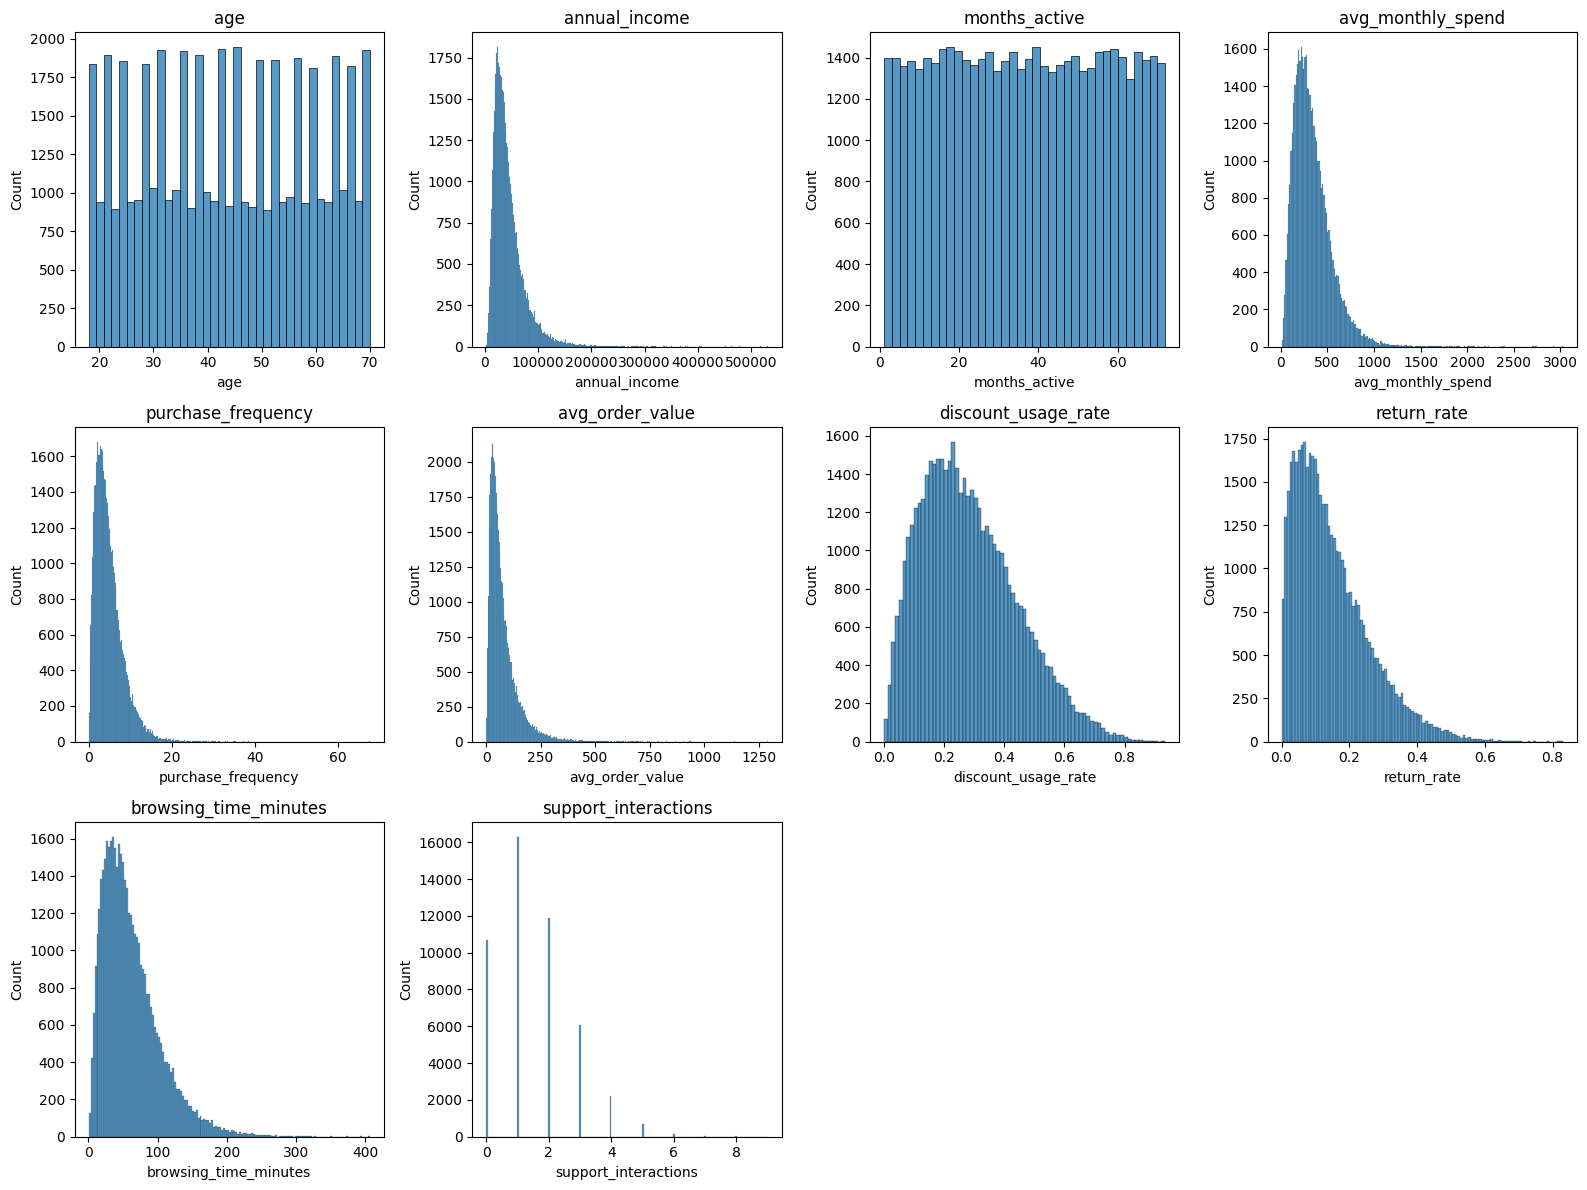

In [7]:
rows = (len(num_cols) + 3) // 4 # dynamic rows 
_, axes = plt.subplots(rows, 4, figsize=(16, 4 * rows))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.histplot(df, x=col, bins='auto', ax=ax)
    ax.set_title(col)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

---

## **Univariate Analysis**

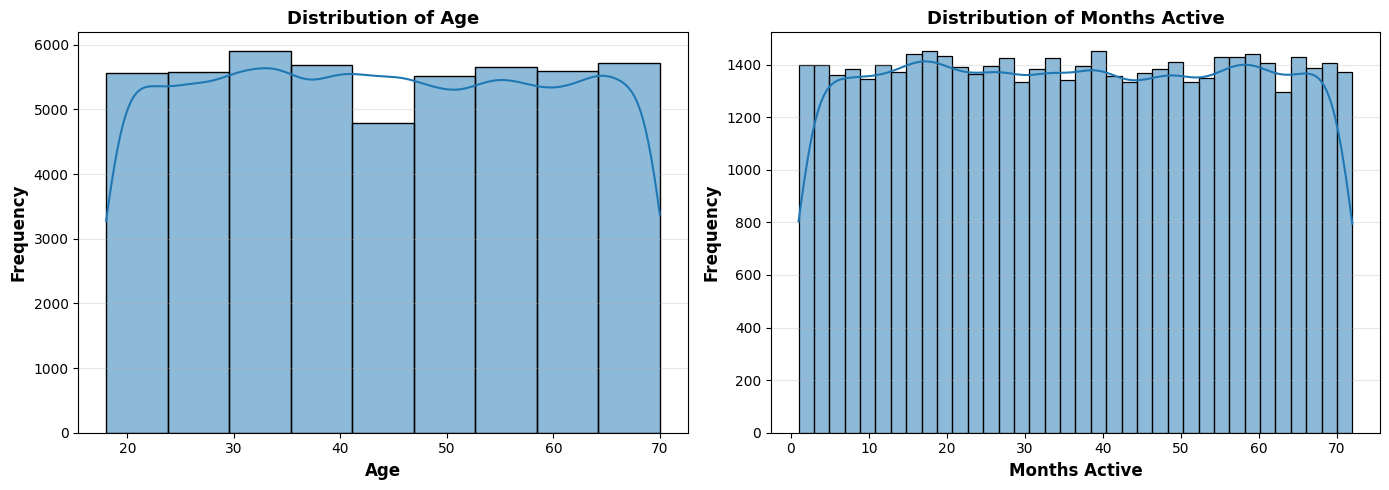

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age histogram
sns.histplot(df, x='age', bins=9, ax=axes[0], kde=True, edgecolor='black')
axes[0].set_xlabel('Age', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('Distribution of Age', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Months Active histogram
sns.histplot(df, x='months_active', bins='auto', ax=axes[1], kde=True, edgecolor='black')
axes[1].set_xlabel('Months Active', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title('Distribution of Months Active', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

`age` (18-70) and `months_active` (1-72) both have somewhat uniform distributions. 

This suggests that there was even sampling across demographics and tenure groups.

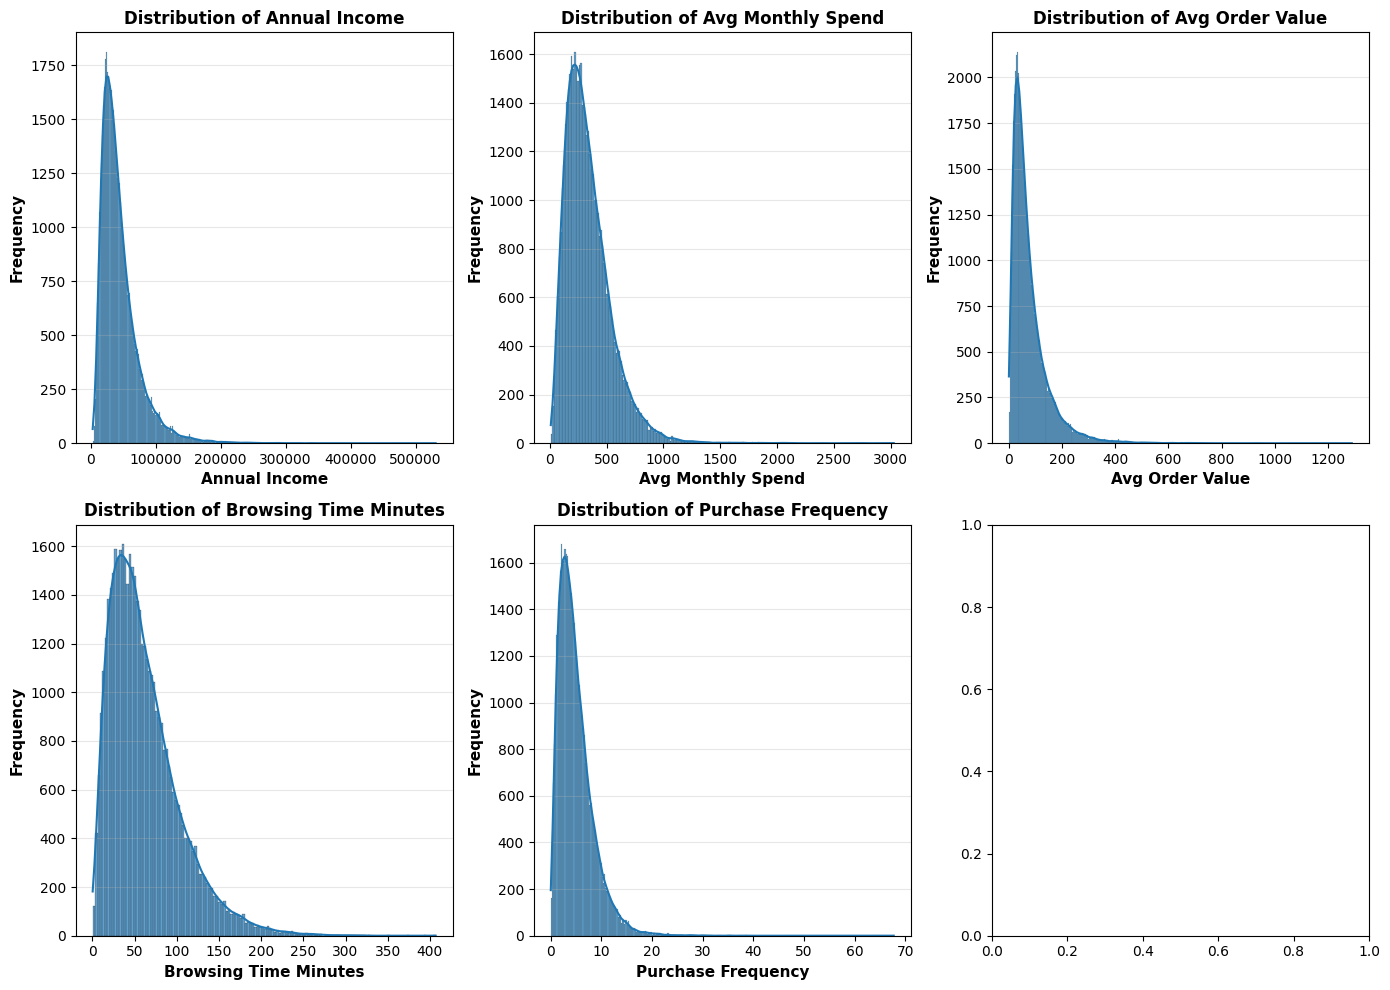

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 10))
axes = axes.flatten()

variables = ['annual_income', 'avg_monthly_spend', 'avg_order_value', 'browsing_time_minutes', 'purchase_frequency']

for ax, var in zip(axes, variables):
    sns.histplot(df, x=var, bins='auto', ax=ax, kde=True, edgecolor='black', alpha=0.7)
    ax.set_xlabel(var.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title(f'Distribution of {var.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

`annual_income`, `avg_monthly_spend`, `avg_order_value`, `browsing_time_minutes`, and `puchase_frequency`: all have right-skewed distributions. 

This means that most customers cluster at the moderate values, but there is a small group or an individual that just spends greatly more. `browsing_time_minutes`, for example, saw one dude spending over 400 minutes browsing, while most just cluster at around 30-60 mns.

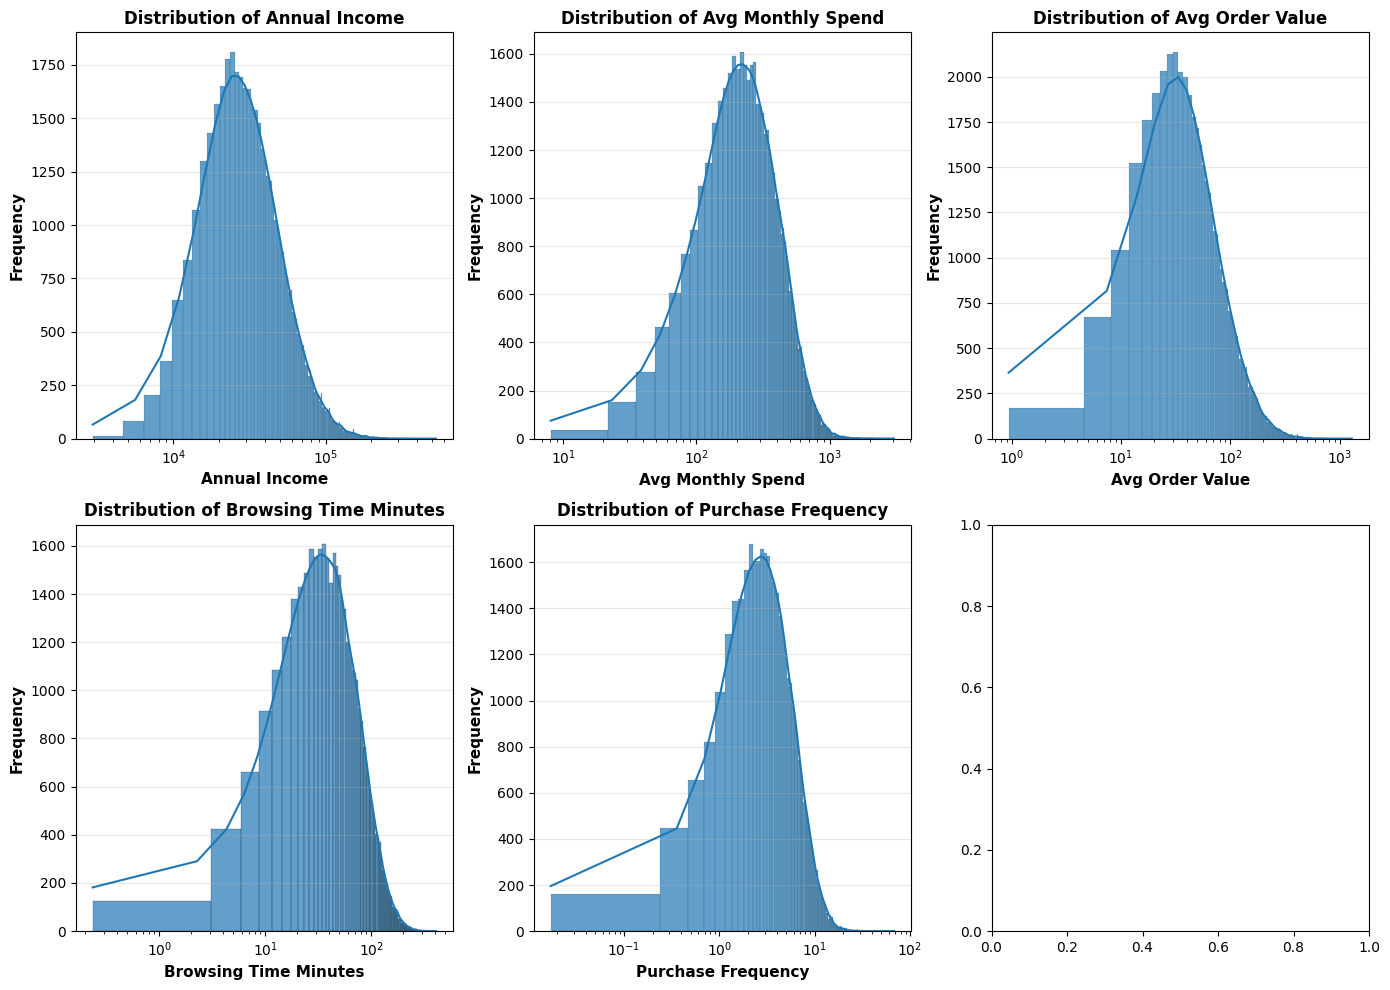

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(14, 10))
axes = axes.flatten()

variables = ['annual_income', 'avg_monthly_spend', 'avg_order_value', 'browsing_time_minutes', 'purchase_frequency']

for ax, var in zip(axes, variables):
    sns.histplot(df, x=var, bins='auto', ax=ax, kde=True, edgecolor='black', alpha=0.7)
    ax.set_xscale('log')
    ax.set_xlabel(var.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title(f'Distribution of {var.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

When applied logarithm scaling, we can see:
- `annual_income` and `avg_monthly_spend` seem to have symmetric bell, and follows the KDE curve. They are an example of *log-normality* in the set.
- `purchase_order_value`, `browsing_time_minutes`, and `purchase_frequency` seem to roughly have bell-shaped too, but they have heavy left tail, suggeting some deviation.

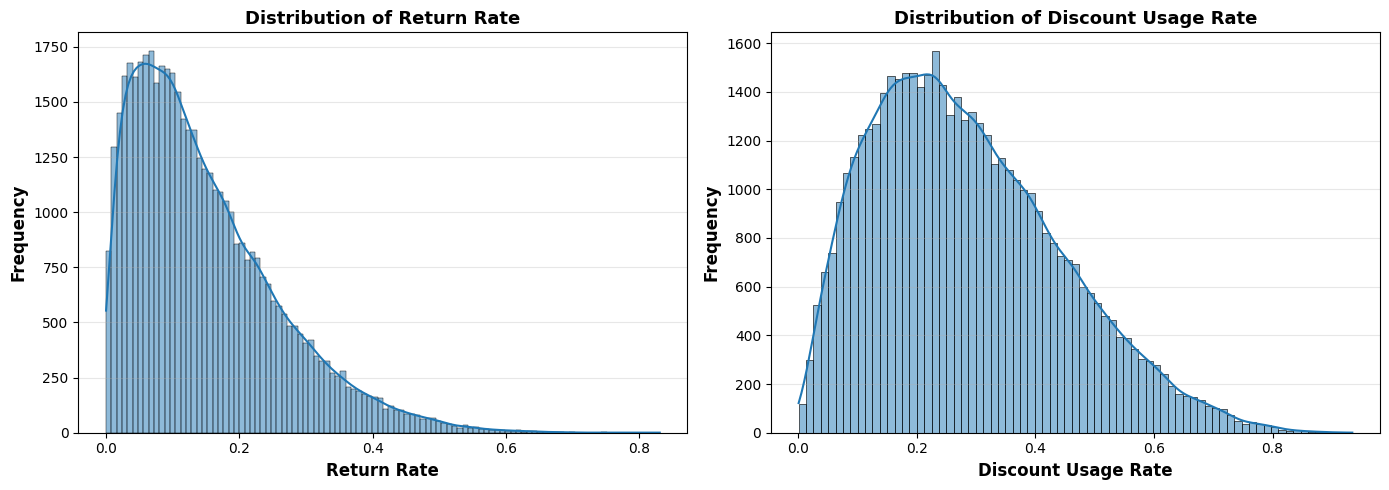

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Return Rate histogram
sns.histplot(df, x='return_rate', ax=axes[0], kde=True, edgecolor='black')
axes[0].set_xlabel('Return Rate', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('Distribution of Return Rate', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Discount Usage Rate histogram
sns.histplot(df, x='discount_usage_rate', bins='auto', ax=axes[1], kde=True, edgecolor='black')
axes[1].set_xlabel('Discount Usage Rate', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title('Distribution of Discount Usage Rate', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


`return_rate`: concentrated in around 0 - 0.2 range. This shows how much of each customer’s total purchases ended up being returned (for exchange, refund, or other purposes…). This is somewhat lower than the average real-world return rate for an online retail store, 24.5% (Capital One Shopping, 2026). Maximum return rate reaches 0.83.

`discount_usage_rate`: concentrated in the 0-0.4 range. This shows how much of customer’s purchases involved a discount. This again, relates to real-world statistics, where the average discount usage rate can range from 10% to 30% (OpenSend, 2025). However, according to the graph, a noticeable amount of customers are driven by discounts, with ranges up to 0.93.

<Axes: xlabel='support_interactions', ylabel='count'>

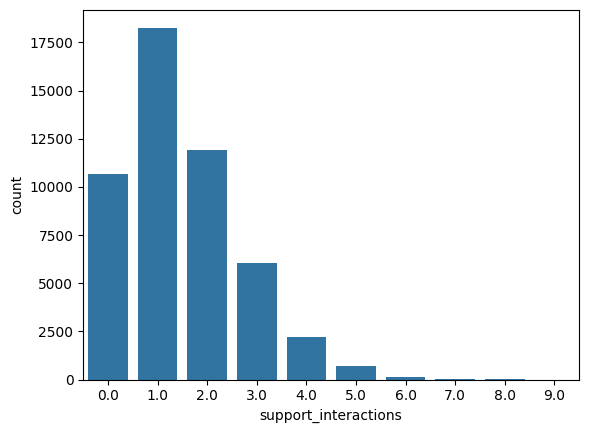

In [111]:
sns.countplot(df, x='support_interactions')

`support_interactions`: Poisson-distributed as expected from the dataset description, heavily concentrated at 0-2 interactions. The histogram shows the characteristic right-skewed, discrete shape, with most customers having 0–2 interactions and frequency declining sharply beyond that. The sample mean (1.47) and variance (1.44) are approximately equal, satisfying the key Poisson proper.

In [112]:
from scipy.stats import poisson, chi2_contingency
from scipy.special import factorial

# ── Step 1: Estimate lambda (Poisson parameter = mean) ───────────────────────
lambda_est = df['support_interactions'].mean()
print(f"Estimated λ (mean) : {lambda_est:.4f}")
print(f"Variance            : {df['support_interactions'].var():.4f}")
print(f"Mean ≈ Variance?    : {'✓ Yes' if abs(lambda_est - df['support_interactions'].var()) < 0.5 else '✗ No'}")

Estimated λ (mean) : 1.4749
Variance            : 1.4416
Mean ≈ Variance?    : ✓ Yes


In [15]:
cat_cols = df.select_dtypes(exclude='number').columns
cat_cols

Index(['payment_method', 'region', 'customer_segment'], dtype='object')

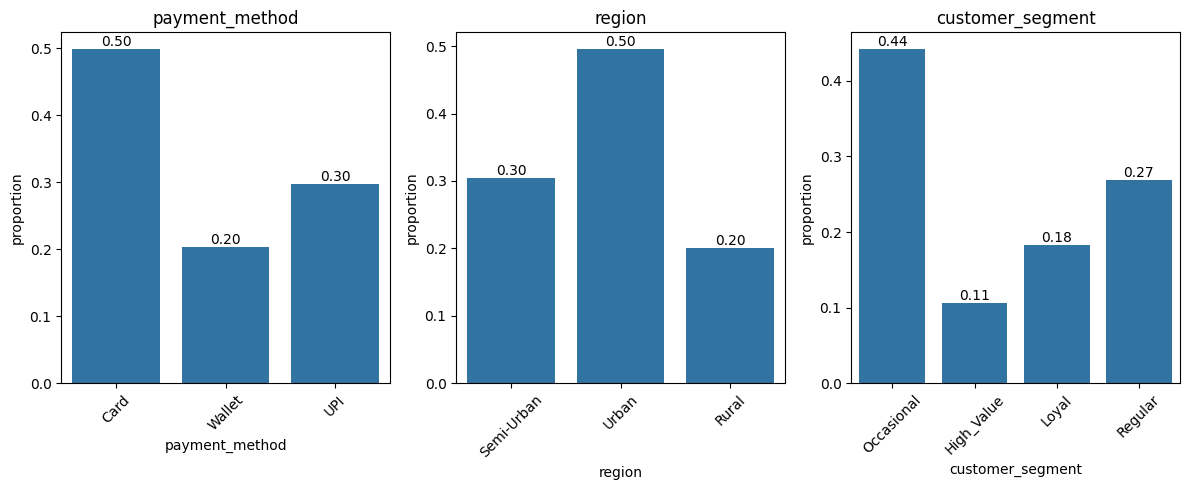

In [16]:
# Graphical Representation of qualitative columns

_, axes = plt.subplots(1, 3, figsize=(12, 5))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df, x=col, ax=ax, stat='proportion')
    ax.bar_label(ax.containers[0], fmt='%.2f')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

`payment_method`: 3 methods: Card, UPI, and Wallet. Seems to follow a 50-30-20% distribution. 

`region`: 3 regions: Urban, Semi-Urban, and Rural. Again, also seems to follow a 50-30-20% distribution.

`customer_segment` (target variable): imbalanced target — Occasional (44.2%) dominates, with High_Value (10.5%) as the clear minority class.

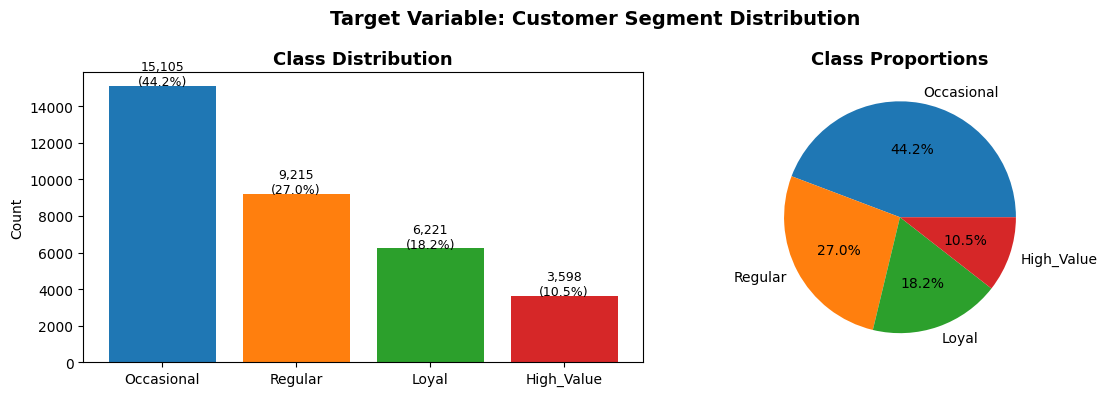

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
segment_counts = df['customer_segment'].value_counts().reindex(segment_order)
axes[0].bar(segment_counts.index, segment_counts.values, color=['#1f77b4','#ff7f0e','#2ca02c','#d62728'])
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(segment_counts.values):
    axes[0].text(i, v + 50, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)

# Pie chart
axes[1].pie(segment_counts.values, labels=segment_counts.index,
            autopct='%1.1f%%', colors=['#1f77b4','#ff7f0e','#2ca02c','#d62728'])
axes[1].set_title('Class Proportions', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Customer Segment Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## **Handling Null Values**

Identifying Missing values in each column

In [34]:
na_by_cols = df.isna().sum() / df.shape[0] * 100

In [35]:
na_by_cols.sort_values(ascending=False)

browsing_time_minutes    7.868
annual_income            6.150
discount_usage_rate      5.098
avg_monthly_spend        5.040
return_rate              4.974
support_interactions     3.976
purchase_frequency       3.958
months_active            0.000
age                      0.000
avg_order_value          0.000
payment_method           0.000
region                   0.000
customer_segment         0.000
dtype: float64

If we go by the rule of thumb, we can safely remove the rows with missing values on columns with less that 5% missing values, and potentially drop the ones below 10% percent as well. 

In [27]:
df = pd.read_csv("retail_customer_segmentation.csv")

In [28]:
rows_with_missing = df.isna().any(axis=1).sum()
proportion_rows_with_missing = df.isna().any(axis=1).mean()
print(proportion_rows_with_missing)

0.31722


However, we found that combined 31.72% of the rows have at least one missing value, which is a lot, so removing them would result in significant loss in healthy data in other columns. 

- So let's study the nature of the missing data first before we decide on how to handle it.

### **Studying Missingness Nature**

We will study the distribution of columns without missing data before and after the removal of rows with missing values to see if there is a significant difference in the distribution, which would indicate that the missing data is not random and may be related to the values in those columns.

In [36]:
NA_list = []
NoNA_list = []

for i in range(len(na_by_cols)):
    if na_by_cols.values[i] > 0:
        NA_list.append(na_by_cols.index[i])
    else:
        NoNA_list.append(na_by_cols.index[i])

In [37]:
# Columns that has missing values

NA_list

['annual_income',
 'avg_monthly_spend',
 'purchase_frequency',
 'discount_usage_rate',
 'return_rate',
 'browsing_time_minutes',
 'support_interactions']

In [38]:
# Columns with no missing values

NoNA_list

['age',
 'months_active',
 'avg_order_value',
 'payment_method',
 'region',
 'customer_segment']

In [39]:
# Dropping the rows with missing value for comparison

cleaned_data = df.dropna()

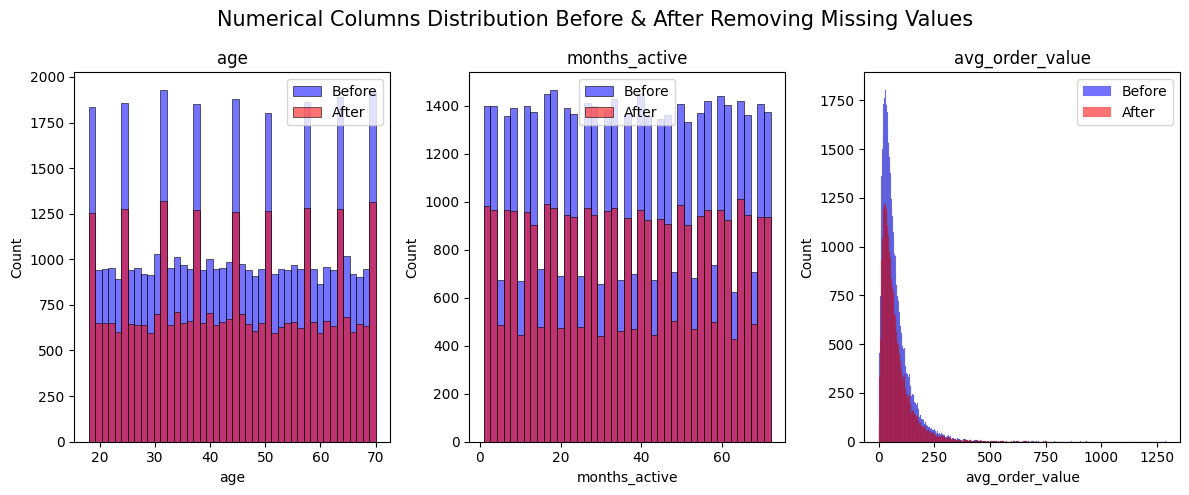

In [40]:
num_NoNA = [col for col in NoNA_list if col in num_cols]

_, axes = plt.subplots(1, 3, figsize=(12, 5))
axes_flat = axes.flatten()

for ax, col in zip(axes_flat, num_NoNA):
    combined = pd.concat([df[col], cleaned_data[col]]).dropna()
    _, bin_edges = np.histogram(combined, bins='auto')

    sns.histplot(df, x=col, ax=ax, bins=bin_edges, label='Before', alpha=0.55, color='blue')
    sns.histplot(cleaned_data, x=col, ax=ax, bins=bin_edges, label='After', alpha=0.55, color='red')
    ax.set_title(col)
    ax.legend()

plt.suptitle('Numerical Columns Distribution Before & After Removing Missing Values', fontsize=15)
plt.tight_layout()
plt.show()

We can see that is **no significant difference** in the distribution of the numerical columns without missing data before and after the removal of rows with missing values and they actually closely follow the same distribution, which indicates that the missing data is random and not related to the values in those columns. 

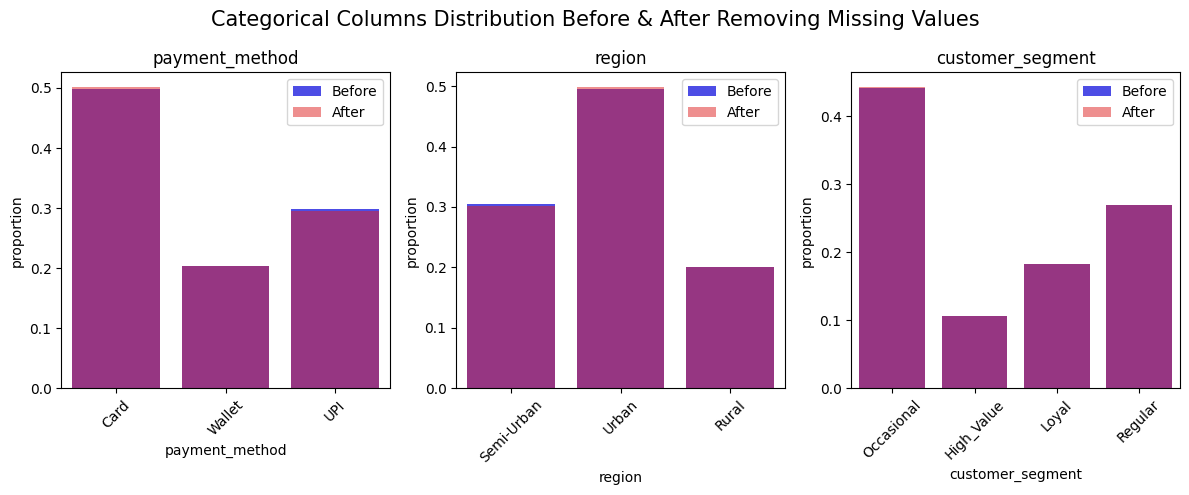

In [41]:
cat_NoNA = [col for col in NoNA_list if col not in num_cols]

_, axes = plt.subplots(1, 3, figsize=(12, 5))
axes_flat = axes.flatten()

for ax, col in zip(axes_flat, cat_NoNA):
    sns.countplot(data=df, x=col, ax=ax, stat='proportion', label='Before', color='blue', alpha=0.8)
    sns.countplot(data=cleaned_data, x=col, ax=ax, stat='proportion', label='After', color='red', alpha=0.5)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
    ax.legend()

plt.suptitle('Categorical Columns Distribution Before & After Removing Missing Values', fontsize=15)
plt.tight_layout()
plt.show()

Similarly, the non-missing categorical columns also see no proportion change after the removal of rows with missing values, which further supports the conclusion that the missing data is random and not related to the values in those columns.

From this, we can conclude that the nature of the missingness is ***Missing Completely at Random (MCAR)***

- Therefore, we should be able to safely remove the rows with missing values without introducing bias to our analysis.a

But then again, from earlier, removing them all is removing 31% of our total 50,000 rows, so I think it wouldn't hurt to just **impute them with the median** instead

In [42]:
cleaned = df.copy()

cleaned[NA_list] = df[NA_list].fillna(df[NA_list].median())

In [43]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer

# Preserves relationships between variables
imputer = IterativeImputer(random_state=42, max_iter=10)
cleaned[NA_list] = imputer.fit_transform(df[NA_list])

**Iterative Imputer** treats missing value imputation as a regression problem. For each column with missing values, it trains a model using all other features as predictors, and uses that model to estimate and fill in the missing values. This process repeats across all incomplete columns, cycling through them multiple times until the imputed values converge.

By default, it uses Bayesian Ridge Regression: fits a linear regression model with automatic regularisation for each incomplete column.

Other options include:
- RandomForestRegressor: Best for Nonlinear relationships between features.
- KNeighborsRegressor: Best for smaller datasets
- ExtraTreesRegressor: Similar to RF, faster on large datasets.

In [44]:
cleaned.isna().sum()

age                      0
annual_income            0
months_active            0
avg_monthly_spend        0
purchase_frequency       0
avg_order_value          0
discount_usage_rate      0
return_rate              0
browsing_time_minutes    0
support_interactions     0
payment_method           0
region                   0
customer_segment         0
dtype: int64

In [45]:
df[NA_list] = df[NA_list].fillna(df[NA_list].median())

In [46]:
df.isna().sum()

age                      0
annual_income            0
months_active            0
avg_monthly_spend        0
purchase_frequency       0
avg_order_value          0
discount_usage_rate      0
return_rate              0
browsing_time_minutes    0
support_interactions     0
payment_method           0
region                   0
customer_segment         0
dtype: int64

---

## **Handling Outliers**

Checking min and max values of numerical columns to identify potential outliers

In [29]:
cleaned[NA_list].describe()

,annual_income,avg_monthly_spend,purchase_frequency,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,44542.693695,337.293988,4.910814,0.284358,0.148964,61.781257,1.494601
std,29583.986898,199.403846,3.347832,0.155125,0.107725,40.067581,1.196756
min,2946.317892,8.072298,0.017013,0.000534,0.000050,0.236109,0.000000
25%,25112.704208,197.220824,2.526421,0.166100,0.066834,32.836514,1.000000
50%,38710.586730,309.826593,4.316086,0.273924,0.130674,56.794457,1.000000
75%,53830.215138,429.191654,6.399534,0.380198,0.203893,79.367471,2.000000
max,530788.317921,3026.342238,67.682528,0.934655,0.830395,406.813006,9.000000


In [30]:
df[NA_list].describe()

,annual_income,avg_monthly_spend,purchase_frequency,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000
mean,44065.695114,335.287469,4.881070,0.283248,0.147704,61.065171,1.47494
std,29642.592692,199.593893,3.351036,0.155198,0.107865,40.142412,1.20065
min,2946.317892,8.072298,0.017013,0.000534,0.000050,0.236109,0.00000
25%,25112.704208,197.220824,2.526421,0.166100,0.066834,32.836514,1.00000
50%,36787.730010,297.477404,4.158673,0.262591,0.123628,52.679175,1.00000
75%,53830.215138,429.191654,6.399534,0.380198,0.203893,79.367471,2.00000
max,530788.317921,3026.342238,67.682528,0.934655,0.830395,406.813006,9.00000


In [31]:
data = pd.read_csv("retail_customer_segmentation.csv")[NA_list].describe()
data

,annual_income,avg_monthly_spend,purchase_frequency,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions
count,46925.000000,47480.000000,48021.000000,47451.000000,47513.000000,46066.000000,48012.000000
mean,44542.620904,337.294238,4.910841,0.284358,0.148964,61.781329,1.494606
std,30537.946035,204.627095,3.416115,0.159236,0.110508,41.743394,1.221280
min,2946.317892,8.072298,0.017013,0.000534,0.000050,0.236109,0.000000
25%,24373.244554,192.074544,2.456867,0.160497,0.063938,31.082283,1.000000
50%,36787.730010,297.477404,4.158673,0.262591,0.123628,52.679175,1.000000
75%,55497.245522,439.112361,6.526903,0.387640,0.209612,82.549571,2.000000
max,530788.317921,3026.342238,67.682528,0.934655,0.830395,406.813006,9.000000


The `InterativeImputer` seems to be *a bit*, just a bit more accurate to the stats of the original value

In [47]:
num_cols

Index(['age', 'annual_income', 'months_active', 'avg_monthly_spend',
       'purchase_frequency', 'avg_order_value', 'discount_usage_rate',
       'return_rate', 'browsing_time_minutes', 'support_interactions'],
      dtype='object')

In [48]:
for var in num_cols:
    print(f"Mean   of {var}: {df[var].mean():.2f}")
    print(f"Median of {var}: {df[var].median():.2f}")
    print()

Mean   of age: 44.00
Median of age: 44.00

Mean   of annual_income: 44065.70
Median of annual_income: 36787.73

Mean   of months_active: 36.48
Median of months_active: 36.00

Mean   of avg_monthly_spend: 335.29
Median of avg_monthly_spend: 297.48

Mean   of purchase_frequency: 4.88
Median of purchase_frequency: 4.16

Mean   of avg_order_value: 77.38
Median of avg_order_value: 56.60

Mean   of discount_usage_rate: 0.28
Median of discount_usage_rate: 0.26

Mean   of return_rate: 0.15
Median of return_rate: 0.12

Mean   of browsing_time_minutes: 61.07
Median of browsing_time_minutes: 52.68

Mean   of support_interactions: 1.47
Median of support_interactions: 1.00



Surprisingly, we got same statistical value before and after imputing (prolly the dataset's author wanted it this way, I guess)

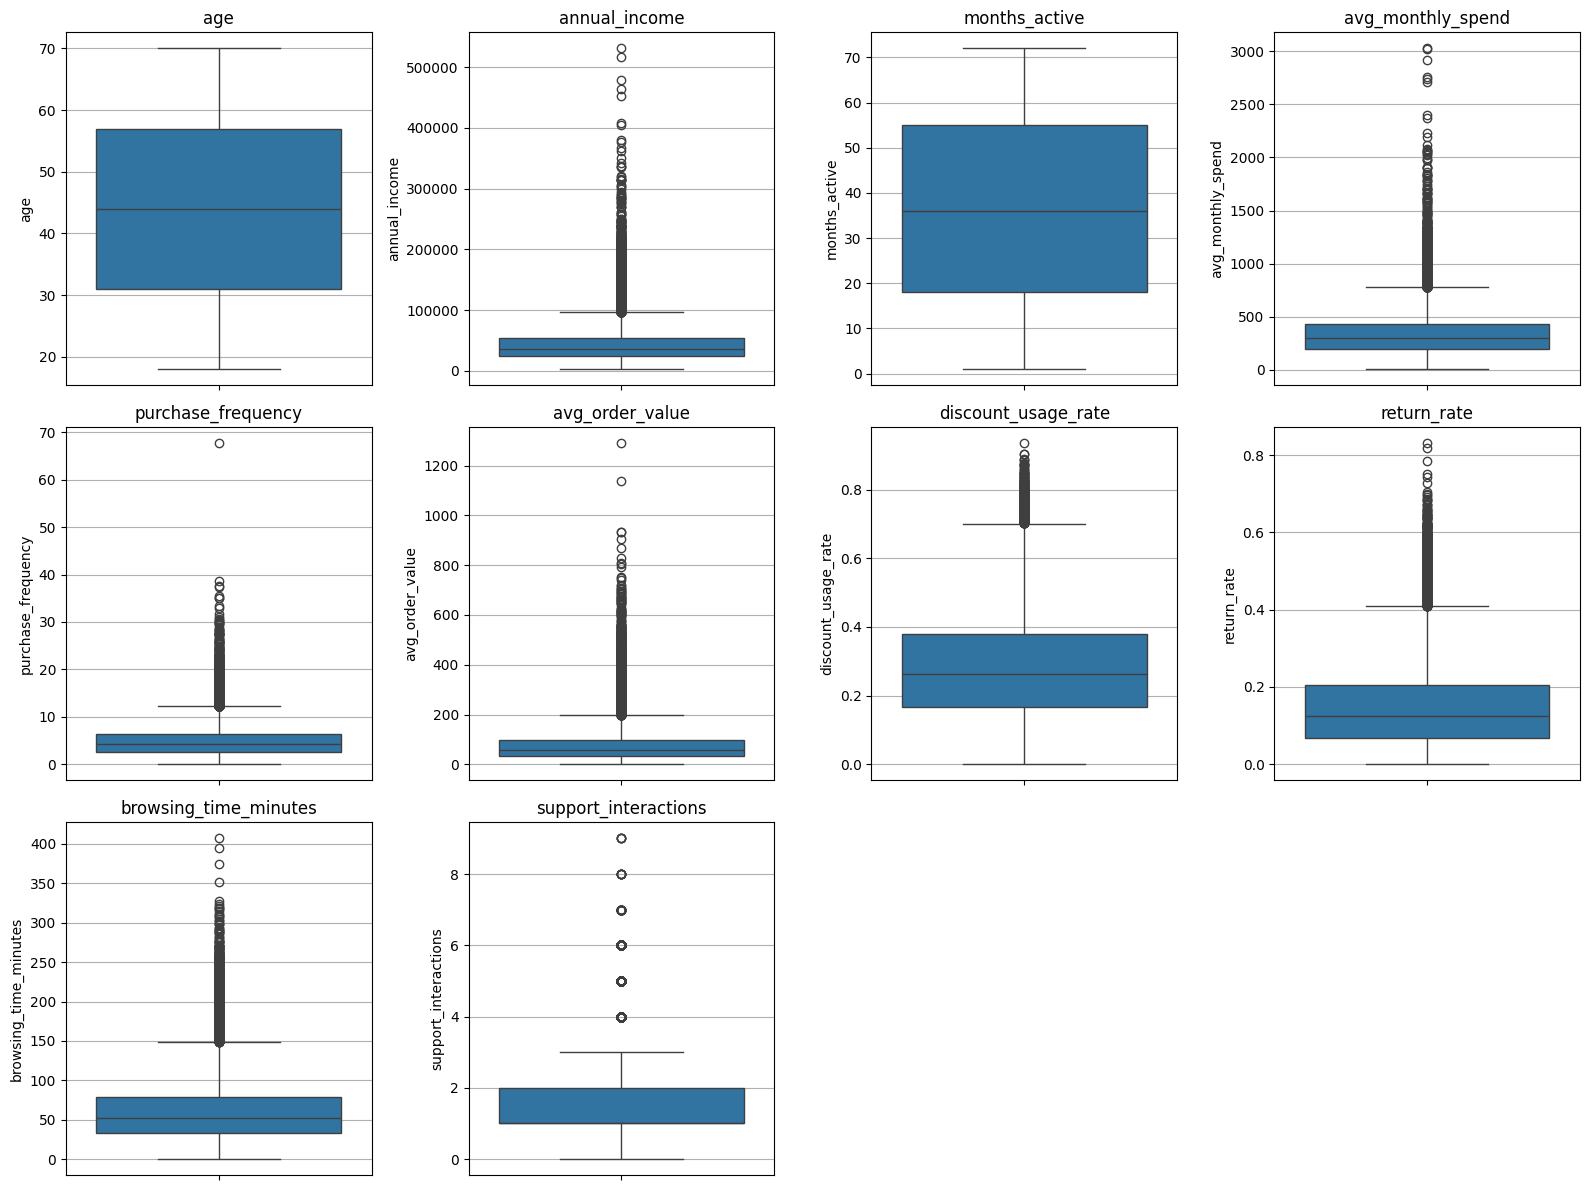

In [34]:
rows = (len(num_cols) + 3) // 4
_, axes = plt.subplots(rows, 4, figsize=(16, 4 * rows))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.boxplot(df, y=col, ax=ax)
    ax.set_title(col)
    ax.grid(axis='y')

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Although we can see some extreme values in the max values compared to its median for most of the columns except age and months active, we will not deal with them for now as they all seem reasonable enough to happen in real life and not from the result of an error.

- Keeping them in our dataset could also be beneficial as they can help us identify high-value customers and their characteristics, which is important for customer segmentation.

---

# **Exploratory Data Analysis**

Finding the relationship between columns and identifying potential patterns in the data that can help us in customer segmentation

Before looking into potential meaningful relationships between the columns let's build a matrix that we can get a holistic view of the relationships between all the columns in one place, and then we can look into specific relationships that we find interesting.

In [21]:
from scipy import stats
from scipy.stats import chi2_contingency
import itertools

We want the matrix heatmap to be consistent with valuescranging from 0 to 1 so we will use these metrics for each combination of columns:

- Numerical-Numerical: We will use **Spearman's correlation coefficient** to find monotonic relationships and is not affected by outliers.
- Numerical-categorical: we will use **eta_squared** to find the strength of association between the numerical and categorical variables.
- Categorical-categorical: we will use **Cramer's V** to normalize chi-square values between 0 and 1

In [22]:
# Helper functions to calculate cramers_v and eta_squared

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(r - 1, k - 1))

def eta_squared(numerical, categorical):
    groups = [numerical[categorical == cat].dropna() 
              for cat in categorical.unique()]
    grand_mean = numerical.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total = ((numerical - grand_mean)**2).sum()
    return ss_between / ss_total if ss_total != 0 else 0


In [23]:
all_cols = df.columns.to_list()
all_cols

['age',
 'annual_income',
 'months_active',
 'avg_monthly_spend',
 'purchase_frequency',
 'avg_order_value',
 'discount_usage_rate',
 'return_rate',
 'browsing_time_minutes',
 'support_interactions',
 'payment_method',
 'region',
 'customer_segment']

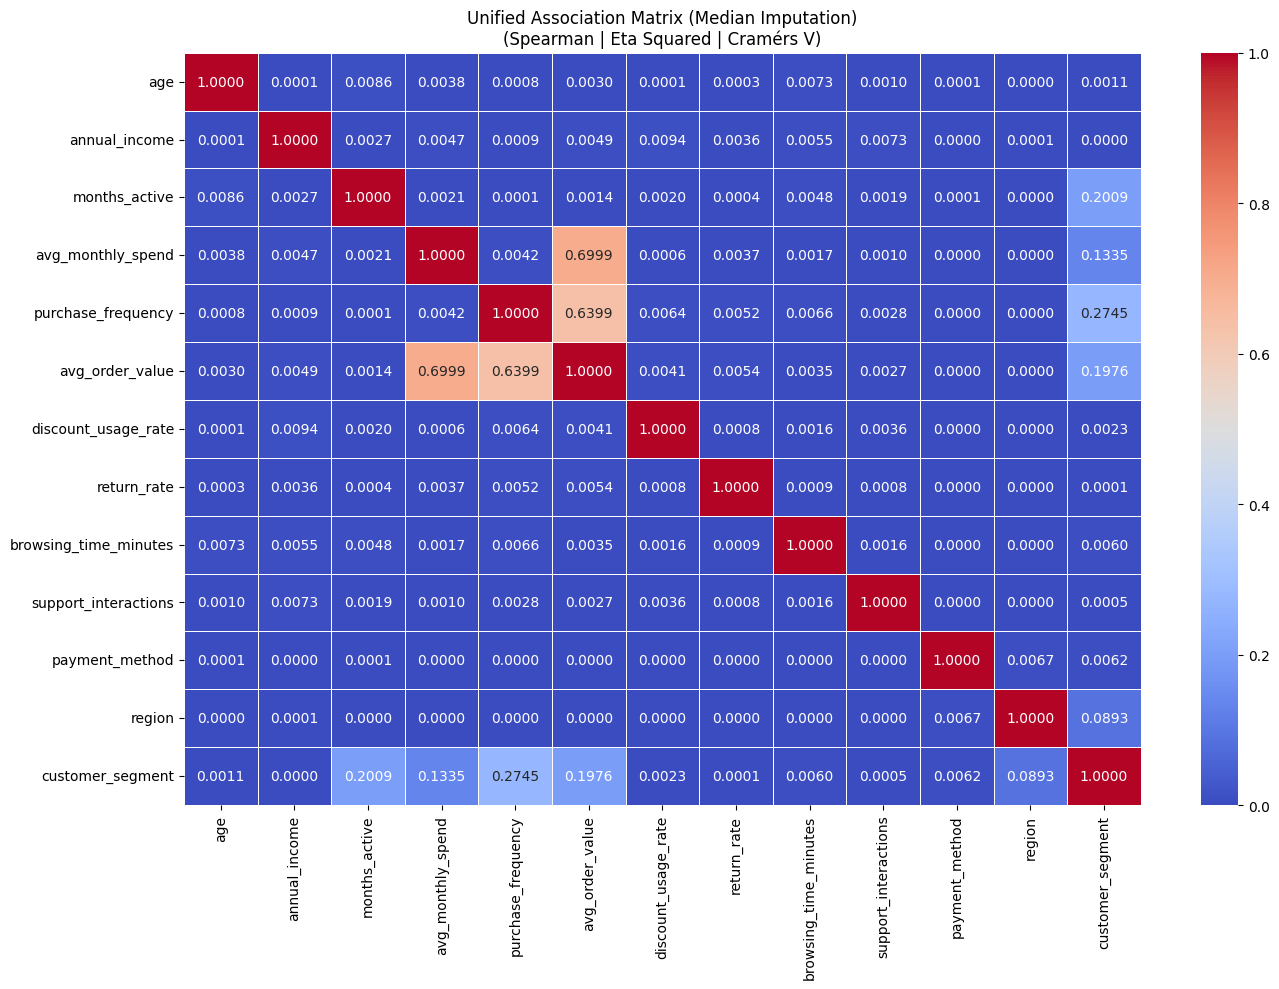

In [49]:
# Build empty matrix
corr_matrix = pd.DataFrame(np.zeros((len(all_cols), len(all_cols))),
                            index=all_cols, columns=all_cols)

# Fill matrix
for col1, col2 in itertools.combinations_with_replacement(all_cols, 2):
    if col1 == col2:
        corr_matrix.loc[col1, col2] = 1.0
    elif col1 in num_cols and col2 in num_cols:
        r, _ = stats.spearmanr(df[col1], df[col2])
        corr_matrix.loc[col1, col2] = abs(r)
        corr_matrix.loc[col2, col1] = abs(r)
    elif col1 in cat_cols and col2 in cat_cols:
        v = cramers_v(df[col1], df[col2])
        corr_matrix.loc[col1, col2] = v
        corr_matrix.loc[col2, col1] = v
    else:
        num = col1 if col1 in num_cols else col2
        cat = col1 if col1 in cat_cols else col2
        eta2 = eta_squared(df[num], df[cat][df[num].notna()])
        corr_matrix.loc[num, cat] = eta2
        corr_matrix.loc[cat, num] = eta2

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.4f', cmap='coolwarm',
            vmin=0, vmax=1, linewidths=0.5)
plt.title('Unified Association Matrix (Median Imputation)\n(Spearman | Eta Squared | Cramérs V)')
plt.tight_layout()
plt.show()

In [50]:
corr_matrix

,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions,payment_method,region,customer_segment
age,1.000000,0.000090,0.008631,0.003790,0.000827,0.002969,0.000077,0.000275,0.007302,0.001027,0.000072,0.000019,0.001111
annual_income,0.000090,1.000000,0.002740,0.004664,0.000910,0.004871,0.009360,0.003611,0.005544,0.007256,0.000039,0.000060,0.000028
months_active,0.008631,0.002740,1.000000,0.002057,0.000101,0.001396,0.002019,0.000385,0.004807,0.001884,0.000092,0.000042,0.200911
avg_monthly_spend,0.003790,0.004664,0.002057,1.000000,0.004166,0.699946,0.000567,0.003714,0.001732,0.000978,0.000005,0.000008,0.133454
purchase_frequency,0.000827,0.000910,0.000101,0.004166,1.000000,0.639860,0.006392,0.005245,0.006583,0.002842,0.000006,0.000010,0.274467
avg_order_value,0.002969,0.004871,0.001396,0.699946,0.639860,1.000000,0.004106,0.005362,0.003534,0.002727,0.000002,0.000005,0.197603
discount_usage_rate,0.000077,0.009360,0.002019,0.000567,0.006392,0.004106,1.000000,0.000785,0.001555,0.003647,0.000020,0.000032,0.002259
return_rate,0.000275,0.003611,0.000385,0.003714,0.005245,0.005362,0.000785,1.000000,0.000908,0.000751,0.000039,0.000011,0.000054
browsing_time_minutes,0.007302,0.005544,0.004807,0.001732,0.006583,0.003534,0.001555,0.000908,1.000000,0.001558,0.000014,0.000037,0.005952
support_interactions,0.001027,0.007256,0.001884,0.000978,0.002842,0.002727,0.003647,0.000751,0.001558,1.000000,0.000026,0.000027,0.000499


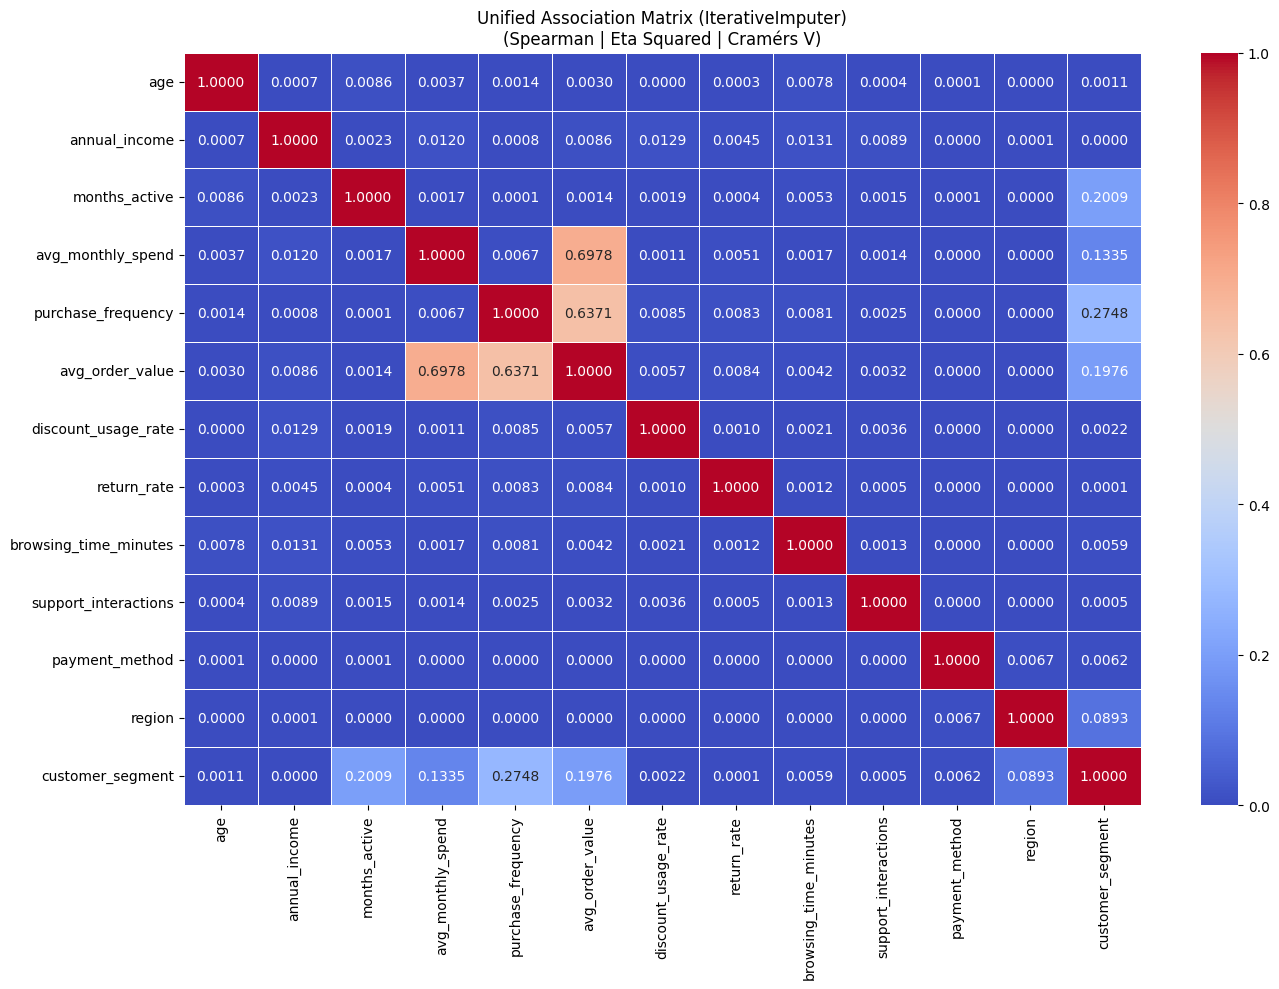

In [51]:
# Build empty matrix
corr_matrix_iterative = pd.DataFrame(np.zeros((len(all_cols), len(all_cols))),
                            index=all_cols, columns=all_cols)

# Fill matrix
for col1, col2 in itertools.combinations_with_replacement(all_cols, 2):
    if col1 == col2:
        corr_matrix_iterative.loc[col1, col2] = 1.0
    elif col1 in num_cols and col2 in num_cols:
        r, _ = stats.spearmanr(cleaned[col1], cleaned[col2])
        corr_matrix_iterative.loc[col1, col2] = abs(r)
        corr_matrix_iterative.loc[col2, col1] = abs(r)
    elif col1 in cat_cols and col2 in cat_cols:
        v = cramers_v(cleaned[col1], cleaned[col2])
        corr_matrix_iterative.loc[col1, col2] = v
        corr_matrix_iterative.loc[col2, col1] = v
    else:
        num = col1 if col1 in num_cols else col2
        cat = col1 if col1 in cat_cols else col2
        eta2 = eta_squared(cleaned[num], cleaned[cat][cleaned[num].notna()])
        corr_matrix_iterative.loc[num, cat] = eta2
        corr_matrix_iterative.loc[cat, num] = eta2

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix_iterative, annot=True, fmt='.4f', cmap='coolwarm',
            vmin=0, vmax=1, linewidths=0.5)
plt.title('Unified Association Matrix (IterativeImputer)\n(Spearman | Eta Squared | Cramérs V)')
plt.tight_layout()
plt.show()

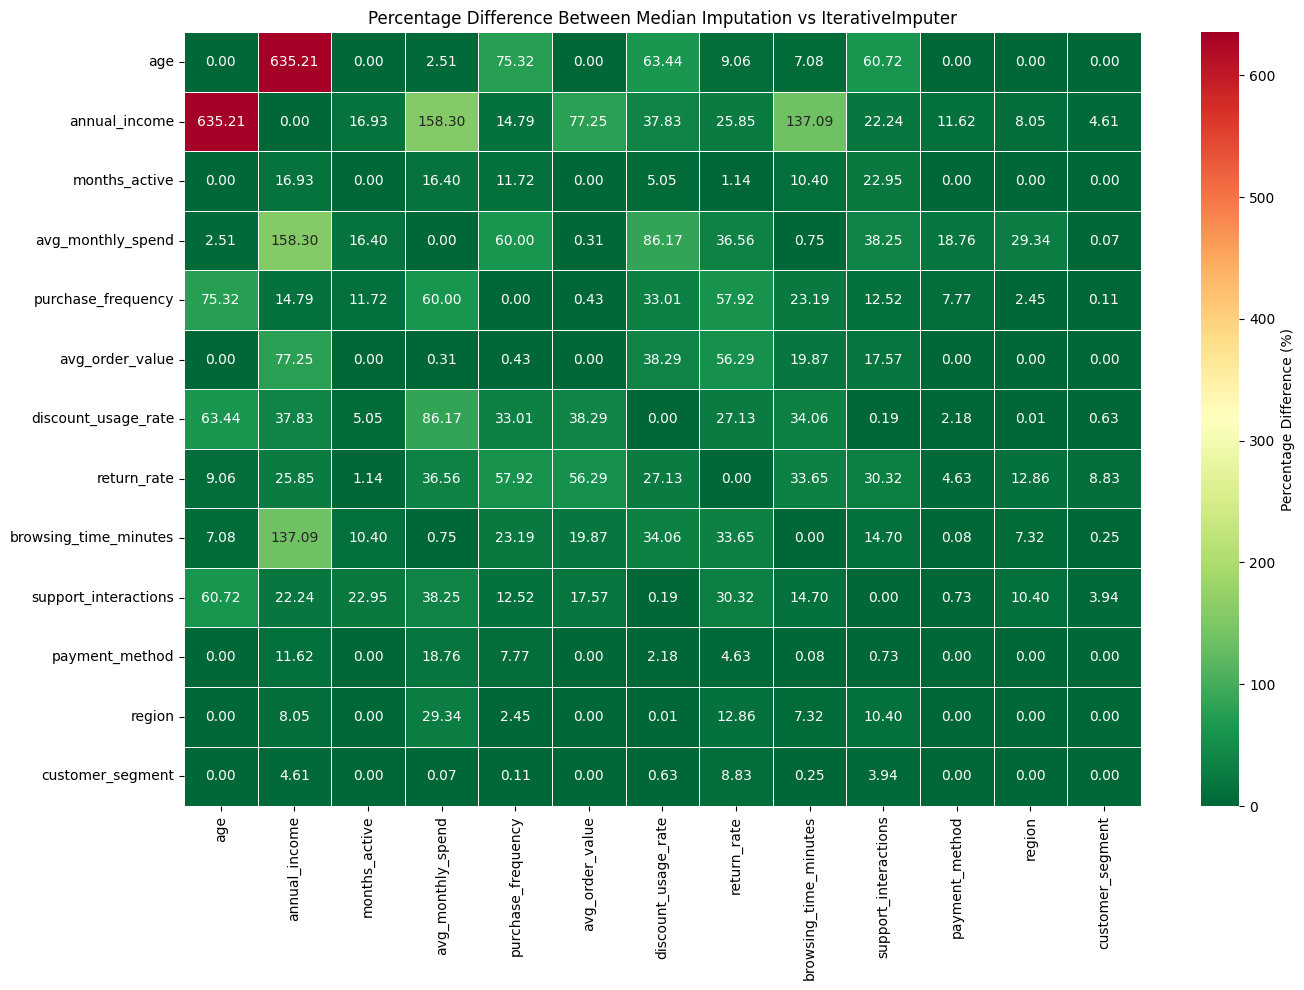

In [52]:
# Calculate percentage difference
# Avoid division by zero
pct_diff = np.where(
    corr_matrix != 0,
    (abs(corr_matrix - corr_matrix_iterative) / abs(corr_matrix)) * 100,
    0
)

pct_diff_matrix = pd.DataFrame(pct_diff, index=all_cols, columns=all_cols)

plt.figure(figsize=(14, 10))
sns.heatmap(pct_diff_matrix, annot=True, fmt='.2f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': 'Percentage Difference (%)'})
plt.title('Percentage Difference Between Median Imputation vs IterativeImputer')
plt.tight_layout()
plt.show()

Very identical heatmap to the Simple Median Imputation

Except for `age` and `annual_income`. They might have meaningful relationships. 

Let's see if we want to switch to `IterativeImputer` or not.

---

#### *UPDATE*: We decided to go with dropping every missing rows instead.
##### Rationale:
- Nature of missingness is Missing Completely at Random (MCAR)
- Misisng values in each features is less than 10% (According to the Rule of Thumb, it is safe to remove; with cautions of course)
- Our dataset already contains lots of data (50,000), removing 31.7% of the data still gives us 34,139 to work with.

In [54]:
# Read CSV and then dropna()

df = pd.read_csv('retail_customer_segmentation.csv').dropna()

In [55]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,34139.0,25054.316442,14411.219057,1.000000,12609.500000,25128.000000,37538.500000,50000.000000
age,34139.0,43.978441,15.258151,18.000000,31.000000,44.000000,57.000000,70.000000
annual_income,34139.0,44627.298079,30652.965127,2946.317892,24440.995368,36905.104779,55595.572087,530788.317921
months_active,34139.0,36.411143,20.834716,1.000000,18.000000,36.000000,55.000000,72.000000
avg_monthly_spend,34139.0,337.521218,204.839884,8.072298,192.924794,297.487317,439.547350,3026.342238
purchase_frequency,34139.0,4.912233,3.428443,0.017013,2.457814,4.161231,6.517651,67.682528
avg_order_value,34139.0,77.568314,70.711639,0.940393,31.984900,56.795897,98.924313,1139.520732
discount_usage_rate,34139.0,0.284557,0.158841,0.000534,0.161122,0.263356,0.387915,0.890329
return_rate,34139.0,0.148519,0.109982,0.000050,0.064033,0.123477,0.208856,0.830395
browsing_time_minutes,34139.0,61.792520,41.693313,0.632568,31.180684,52.692549,82.498637,406.813006


--- 

## **Bivariate Analysis**

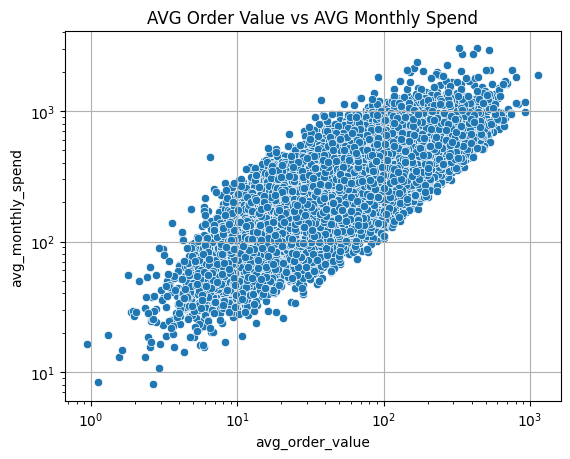

In [56]:
sns.scatterplot(data=df, x='avg_order_value', y='avg_monthly_spend')
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.title("AVG Order Value vs AVG Monthly Spend")
plt.show()

From the graph we see a positive linear relationship between avg_order_value and avg_monthly_spend meaning that as the average order value increases, the average monthly spend also increases, which is expected as the more a customer spends on average per order, the more those valyes add up to the montly spend.

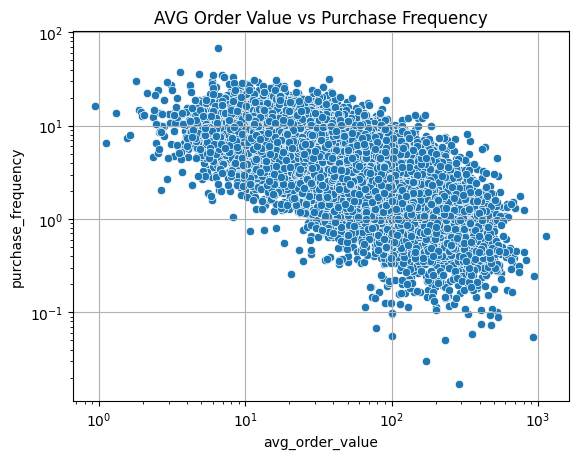

In [57]:
sns.scatterplot(data=df, x='avg_order_value', y='purchase_frequency')
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.title("AVG Order Value vs Purchase Frequency")
plt.show()

From this we seem to see a negative linear relationship between avg_order_value and purchase_frequency, which is interesting as this could indicate that customers who make more frequent purchases tend to have lower average order values, or there might be some other underlying factor at play.

From these two visualizations, it seems The Average Order Value of a customer is postively correlated with their Average Monthly Spend, and negatively correlated with their Purchase Frequency. 

But from the column description, we know that **avg_order_value is calculated by dividing avg_monthly_spend by purchase_frequency**, so these relationships are expected and make sense mathematically as well.

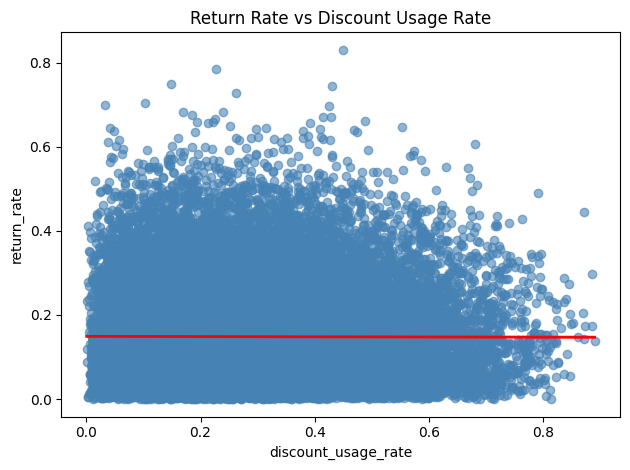

Correlation: -0.00


In [77]:
sns.regplot(df, x='discount_usage_rate', y='return_rate', 
            scatter_kws={'color': 'steelblue', 'alpha': 0.6}, 
            line_kws={'color': 'red', 'linewidth': 2})

plt.title("Return Rate vs Discount Usage Rate")
plt.tight_layout()
plt.show()

rr_dur_corr = df['return_rate'].corr(df['discount_usage_rate'])

print(f"Correlation: {rr_dur_corr:.2f}")

Literally a straight line XD.

Quite a Fun study:

`discount_usage_rate` vs `return_rate`: literally 0 correlation. Hypothetically, one might think deal-seeking customers may drive return rate. However, our data shows otherwise. These 2 seems to have no correlation whatsoever, as the data just scatter all around. 

They appear to be independent customer behaviors.

In [76]:
# Define segment order (can be dict or list)
segment_order = ['Occasional', 'Regular', 'Loyal', 'High_Value']

# Or as a dict if you want more metadata:
# segment_order_dict = {
#     'Occasional': 0,
#     'Regular': 1,
#     'Loyal': 2,
#     'High_Value': 3
# }

--- 

## **Bivariate Analysis Against the Customer Segment**

Text(0.5, 1.0, 'Age Distribution by Customer Segment')

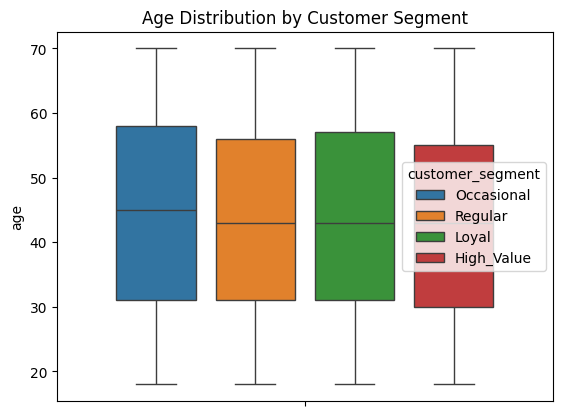

In [78]:
sns.boxplot(df, y='age', hue='customer_segment', hue_order=segment_order, gap=0.2)
plt.title("Age Distribution by Customer Segment")

There seems to be no noticeable difference in `age` that affects the customer status.

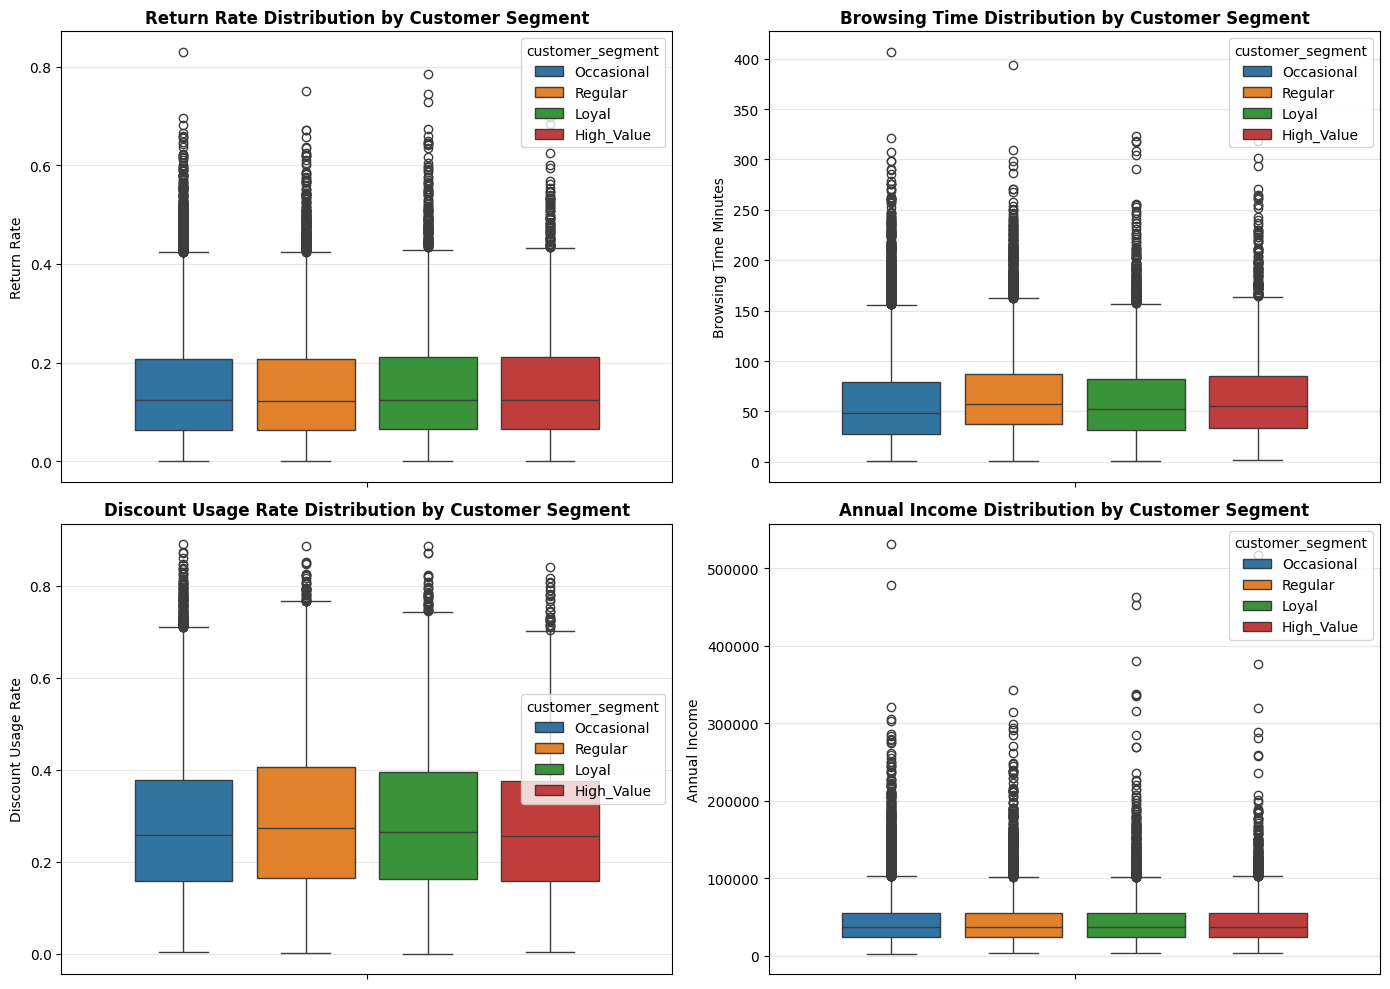

In [79]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

plot_configs = [
    ('return_rate', 'Return Rate Distribution by Customer Segment', False),
    ('browsing_time_minutes', 'Browsing Time Distribution by Customer Segment', False),
    ('discount_usage_rate', 'Discount Usage Rate Distribution by Customer Segment', False),
    ('annual_income', 'Annual Income Distribution by Customer Segment', False)
]

for ax, (feature, title, use_log) in zip(axes, plot_configs):
    sns.boxplot(df, y=feature, hue='customer_segment', gap=0.2, hue_order=segment_order, ax=ax)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(feature.replace('_', ' ').title(), fontsize=10)
    if use_log:
        ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Nor do `return_rate`, `discount_usage_rate`, `browsing_time_minutes`, and `annual_income`. They all provide no **meaningful predictors** for customer segmentation.

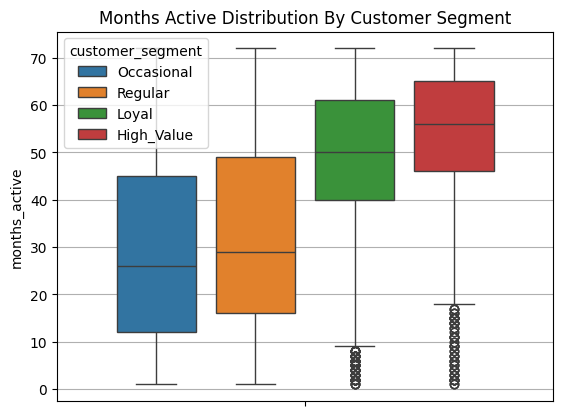

In [59]:
sns.boxplot(df, y='months_active', hue='customer_segment', gap=0.2, hue_order=segment_order)
plt.title("Months Active Distribution By Customer Segment")
plt.grid(axis='y')
plt.show()

We can visually see a difference in the distribution of the numerical columns across the different categories of the target label, which indicates that there is a relationship between them.

- Customers in the 'High Value' segment tend to have been active for a longer time within around 47-65 months, followed by Loyal customer segment with around 40-61 months, and then the 'regular' segment with around 18-48 months, and occasional customers with around 12-45 months.

- Notably, the high value and loyal customer segments also have outliers that have been active for shorter amount of time, which could indicate that they have other behaviors that make them high value or loyal customers despite being active for a shorter time.

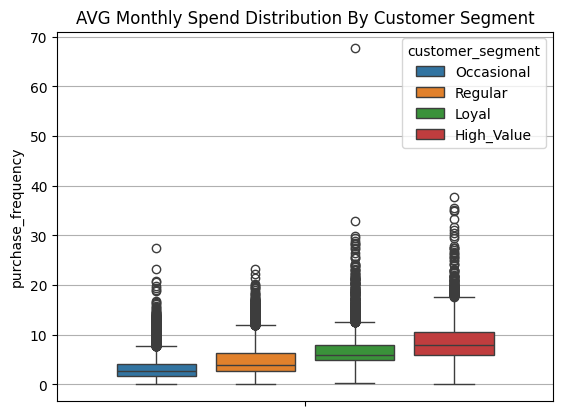

In [61]:
sns.boxplot(df, y='purchase_frequency', hue='customer_segment', gap=0.2, hue_order=segment_order)
plt.title("AVG Monthly Spend Distribution By Customer Segment")
# plt.yscale('log')
plt.grid(axis='y')
plt.show()

`avg_monthly_spend` vs `customer_segment`: Purchase frequency increases progressively from Occasional to High_Value, with medians of approximately 3, 5, 7, and 9 respectively. This is one of the cleaner separations observed across all features, suggesting purchase frequency is a reliable behavioural indicator of segment.

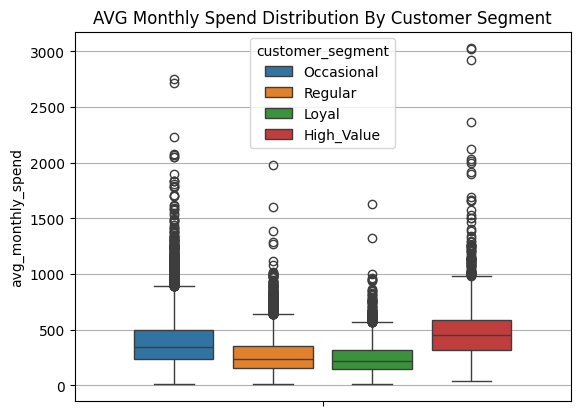

In [60]:
sns.boxplot(df, y='avg_monthly_spend', hue='customer_segment', gap=0.2, hue_order=segment_order)
plt.title("AVG Monthly Spend Distribution By Customer Segment")
# plt.yscale('log')
plt.grid(axis='y')
plt.show()

`avg_monthly_spend` vs `custer_segment`: High_Value customers show the highest median monthly spend, followed by Occasional, Regular, and Loyal in surprisingly close proximity. The wide spread of outliers across all segments indicates that spend alone is not a clean separator between segments, consistent with our association matrix findings.

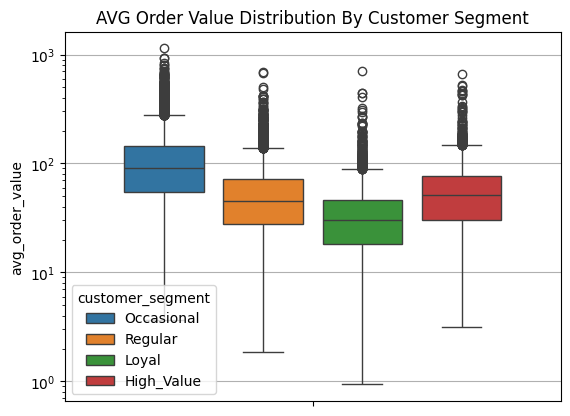

In [62]:
sns.boxplot(df, y='avg_order_value', hue='customer_segment', gap=0.2, hue_order=segment_order)
plt.title("AVG Order Value Distribution By Customer Segment")
plt.yscale('log')
plt.grid(axis='y')
plt.show()

Spending **doesn't really** affect their status, according to this graph 

### Categorical-Categorical Relationship with Stacked Countplots 

In [63]:
fig1 = px.histogram(df, x='customer_segment', color='region', category_orders={'customer_segment': segment_order})
fig1.update_layout(width=600, height=400, title='Customer Segment By Region')
fig1.show()

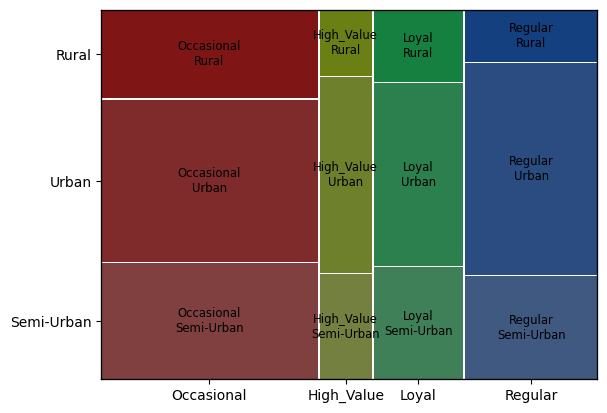

In [64]:
from statsmodels.graphics.mosaicplot import mosaic

mosaic(df, ['customer_segment', 'region'])
plt.show()

There seems to be very minimal differnce between the `regions` that differetiate customer segmentation. Although it is quite identical, according to the mosaic plot, there is still some bit of differences.

H₀: Customer segment distribution is independent of region — the proportion of each segment is the same across Urban, Semi-Urban, and Rural areas

H₁: Customer segment distribution is NOT independent of region — at least one region has a significantly different segment proportion

In [80]:
from scipy.stats import chi2_contingency

# ── Helper function ───────────────────────────────────────────────────────────
def run_chi2_test(var1, var2, data, alpha=0.05):
    """Run a Chi-squared test of independence between two categorical variables."""
    
    crosstab = pd.crosstab(data[var1], data[var2])
    chi2, p, dof, expected = chi2_contingency(crosstab)
    
    # Cramér's V (effect size)
    n = crosstab.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(crosstab.shape) - 1)))
    
    # Check assumption: no expected frequency < 5
    assumption_met = (expected < 5).sum() == 0
    
    print(f"{'='*60}")
    print(f"Chi-squared Test: '{var1}' vs '{var2}'")
    print(f"{'='*60}")
    print(f"  H₀: {var1} and {var2} are independent")
    print(f"  H₁: {var1} and {var2} are NOT independent")
    print(f"  ──────────────────────────────────────")
    print(f"  Chi2 Statistic : {chi2:.4f}")
    print(f"  Degrees of Freedom: {dof}")
    print(f"  P-value        : {p:.6f}")
    print(f"  Cramér's V     : {cramers_v:.4f}  (effect size)")
    print(f"  Assumption Met : {'✓ No expected cell < 5' if assumption_met else '✗ Some expected cells < 5'}")
    print(f"  ──────────────────────────────────────")
    
    if p < alpha:
        print(f"  Result  : ✅ Reject H₀ (p < {alpha})")
        print(f"  Meaning : '{var1}' and '{var2}' are significantly associated.")
    else:
        print(f"  Result  : ❌ Fail to Reject H₀ (p ≥ {alpha})")
        print(f"  Meaning : No significant association found between '{var1}' and '{var2}'.")
    
    # Effect size interpretation
    if cramers_v < 0.1:
        strength = "negligible"
    elif cramers_v < 0.3:
        strength = "weak"
    elif cramers_v < 0.5:
        strength = "moderate"
    else:
        strength = "strong"
    print(f"  Effect  : Association strength is {strength} (Cramér's V = {cramers_v:.4f})")
    print()
    
    return crosstab, chi2, p, dof, cramers_v


# ── Run all three tests ───────────────────────────────────────────────────────
ct1, chi2_1, p1, dof1, v1 = run_chi2_test('customer_segment', 'region',         df)
ct2, chi2_2, p2, dof2, v2 = run_chi2_test('customer_segment', 'payment_method', df)
ct3, chi2_3, p3, dof3, v3 = run_chi2_test('payment_method',   'region',         df)

Chi-squared Test: 'customer_segment' vs 'region'
  H₀: customer_segment and region are independent
  H₁: customer_segment and region are NOT independent
  ──────────────────────────────────────
  Chi2 Statistic : 540.3425
  Degrees of Freedom: 6
  P-value        : 0.000000
  Cramér's V     : 0.0890  (effect size)
  Assumption Met : ✓ No expected cell < 5
  ──────────────────────────────────────
  Result  : ✅ Reject H₀ (p < 0.05)
  Meaning : 'customer_segment' and 'region' are significantly associated.
  Effect  : Association strength is negligible (Cramér's V = 0.0890)

Chi-squared Test: 'customer_segment' vs 'payment_method'
  H₀: customer_segment and payment_method are independent
  H₁: customer_segment and payment_method are NOT independent
  ──────────────────────────────────────
  Chi2 Statistic : 3.7565
  Degrees of Freedom: 6
  P-value        : 0.709585
  Cramér's V     : 0.0074  (effect size)
  Assumption Met : ✓ No expected cell < 5
  ──────────────────────────────────────
  R

According to our test, we can see that `customer_segmentation` do depended on `region`. But their association is not that strong.

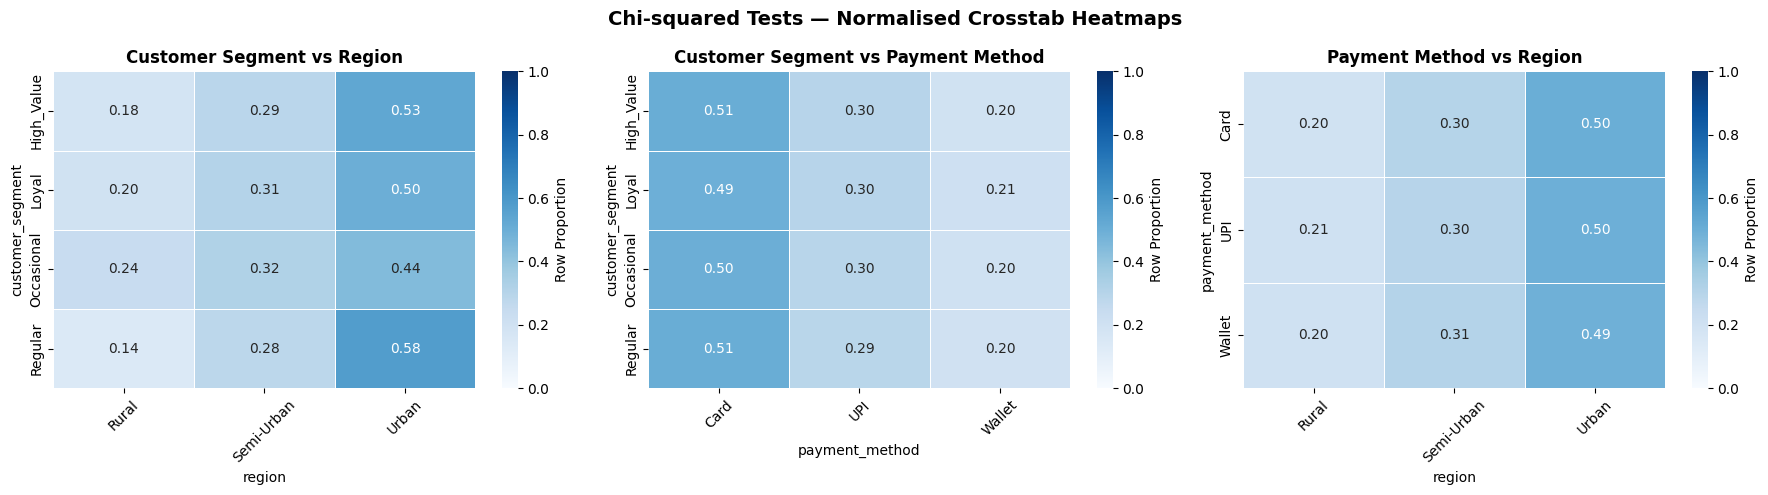

In [81]:
# ── Visualise: Normalised heatmaps for each crosstab ─────────────────────────
tests = [
    (ct1, 'Customer Segment vs Region'),
    (ct2, 'Customer Segment vs Payment Method'),
    (ct3, 'Payment Method vs Region'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (crosstab, title) in zip(axes, tests):
    # Normalise by row so each row sums to 1 (proportions)
    ct_norm = crosstab.div(crosstab.sum(axis=1), axis=0)
    sns.heatmap(ct_norm, annot=True, fmt='.2f', cmap='Blues',
                linewidths=0.5, vmin=0, vmax=1, ax=ax,
                cbar_kws={'label': 'Row Proportion'})
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Chi-squared Tests — Normalised Crosstab Heatmaps', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Every single segment splits almost exactly 50% Card, 30% UPI, 20% Wallet. There is essentially zero relationship between payment method and segment. A High_Value customer and an Occasional customer pay the exact same way on average.

This is a strong, clear finding — payment method tells you nothing about who your customer is.

### Model Development yayyyyyy

In [59]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, label_binarize 

In [60]:
X = df.drop('customer_segment', axis=1)
y = df['customer_segment']

# Label encode target labels
le = LabelEncoder()
y = le.fit_transform(y)
    # use invere_transform to convert back to label names

# Train-Test Split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20,           # 20% for test
    random_state=42,
    stratify=y                # Maintain class distribution
)

print(f"Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

Train: 40000 (80.0%)
Test: 10000 (20.0%)


In [61]:
le.classes_

array(['High_Value', 'Loyal', 'Occasional', 'Regular'], dtype=object)

In [62]:
# One Hot Encode
cat_cols = ['payment_method', 'region']

encoder = OneHotEncoder(sparse_output=False, dtype='int64', drop='first')
encoder.fit(X_train[cat_cols])

# Transform both sets
X_train_encoded = encoder.transform(X_train[cat_cols])
X_test_encoded = encoder.transform(X_test[cat_cols])

# Concat the encoded to the X_train and test
X_train_final = pd.concat([
    X_train[num_cols].reset_index(drop=True),
    pd.DataFrame(X_train_encoded, columns=encoder.get_feature_names_out(cat_cols))
], axis=1)

X_test_final = pd.concat([
    X_test[num_cols].reset_index(drop=True),
    pd.DataFrame(X_test_encoded, columns=encoder.get_feature_names_out(cat_cols))
], axis=1)

In [63]:
X_train_final

,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions,payment_method_UPI,payment_method_Wallet,region_Semi-Urban,region_Urban
0,37,37020.749390,57,85.582822,5.724549,12.726923,0.291526,0.359331,118.413682,0.0,0,0,0,0
1,30,28418.213060,2,386.284556,3.815176,80.222308,0.232820,0.031281,41.348445,1.0,0,0,1,0
2,56,64194.919183,3,248.725785,4.285777,47.055674,0.288422,0.115501,52.679175,0.0,1,0,0,0
3,48,36787.730010,59,108.475708,1.833895,38.277961,0.110703,0.096123,52.679175,3.0,0,0,0,1
4,25,22098.203370,60,129.268467,8.990757,12.938806,0.371200,0.072731,157.087060,0.0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,56,158583.024062,67,478.376806,3.716135,101.434086,0.235549,0.081314,16.518861,0.0,1,0,0,1
39996,33,14156.872057,13,46.442089,2.305552,14.049721,0.192057,0.168565,46.035610,1.0,1,0,0,0
39997,59,32082.621550,64,17.006220,5.594805,2.578730,0.058729,0.039171,73.487697,2.0,0,0,0,1
39998,59,29806.287313,42,514.144904,4.008779,102.648760,0.244997,0.313558,78.084745,1.0,0,0,1,0


In [64]:
# Scale data :))

# Fit scaler on training data only
scaler = StandardScaler()
scaler.fit(X_train_final)

# Transform both sets
X_train_final = scaler.transform(X_train_final)
X_test_final = scaler.transform(X_test_final)


In [65]:
# Import models
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [66]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [67]:
models = {
    'Logistic Regression': LogisticRegression(random_state=43),
    'Gaussian Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=43),
    'Random Forest': RandomForestClassifier(random_state=43, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=43, eval_metric='mlogloss'),
    'CatBoost': CatBoostClassifier(random_state=43, verbose=0)
}

params = {
    'Logistic Regression': {
        'C': [0.1, 1, 10],    # Inverse of Strength of regularization (1/alpha)
        'solver': ['lbfgs', 'liblinear'], 
    },
    'Gaussian Naive Bayes': {
        'var_smoothing': [1e-9]
    },
    'KNN': {
        'n_neighbors': [5, 7, 9],
        'weights': ['uniform']
    },
    'Decision Tree': {
        'max_depth': [10, 15, 20],
        'min_samples_split': [5, 10]
    }, 
    'Random Forest': {
        'n_estimators': [50, 100, 150],
        'max_depth': [10, 15, 20],
        'min_samples_split': [2, 5]
    },
   'XGBoost': {
        'n_estimators': [50, 100, 150],
        'max_depth': [5, 7, 10],
        'learning_rate': [0.01, 0.1, 0.3]
    },
    'CatBoost': {
        'iterations': [50, 100, 150],
        'depth': [6],
        'learning_rate': [0.01, 0.05]
    }
}

In [ ]:

# Train all models
results = {}
 
print("="*70)
print("TRAINING ALL MODELS WITH GRIDSEARCHCV")
print("="*70)

for model_name in models.keys():
    print(f"\n🔄 Training {model_name}...")

    start_time = time.time()
    
    grid_search = GridSearchCV(
        models[model_name],
        params[model_name],
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=0
    )
    
    grid_search.fit(X_train_final, y_train)

    elapsed_time = time.time() - start_time
    
    results[model_name] = {
        'model': grid_search.best_estimator_,
        'best_params': grid_search.best_params_,
        'cv_score': grid_search.best_score_,
        'test_score': grid_search.score(X_test_final, y_test),
        'train_time': elapsed_time
    }
    
    print(f"✓ CV Score: {grid_search.best_score_:.4f} | Test Score: {grid_search.score(X_test_final, y_test):.4f} | Test Score: {grid_search.score(X_test_final, y_test):.4f} | Time: {elapsed_time:.2f}s")

TRAINING ALL MODELS WITH GRIDSEARCHCV

🔄 Training Logistic Regression...


✓ CV Score: 0.6365 | Test Score: 0.6362 | Test Score: 0.6362 | Time: 23.19s

🔄 Training Gaussian Naive Bayes...
✓ CV Score: 0.5739 | Test Score: 0.5791 | Test Score: 0.5791 | Time: 0.27s

🔄 Training KNN...
✓ CV Score: 0.6168 | Test Score: 0.6300 | Test Score: 0.6300 | Time: 28.83s

🔄 Training Decision Tree...
✓ CV Score: 0.7275 | Test Score: 0.7294 | Test Score: 0.7294 | Time: 4.49s

🔄 Training Random Forest...
✓ CV Score: 0.7545 | Test Score: 0.7643 | Test Score: 0.7643 | Time: 131.23s

🔄 Training XGBoost...
✓ CV Score: 0.7604 | Test Score: 0.7674 | Test Score: 0.7674 | Time: 157.45s

🔄 Training CatBoost...
✓ CV Score: 0.7539 | Test Score: 0.7598 | Test Score: 0.7598 | Time: 35.68s


In [ ]:
# Summary
print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)

summary_df = pd.DataFrame({
    'Model': results.keys(),
    'CV Score': [results[m]['cv_score']for m in results.keys()],
    'Test Score': [results[m]['test_score'] for m in results.keys()],
    'Train Time (s)': [results[m]['train_time'] for m in results.keys()]
})

summary_df = summary_df.sort_values('Test Score', ascending=False).reset_index(drop=True)
print(summary_df.to_string(index=False))


MODEL COMPARISON SUMMARY
               Model  CV Score  Test Score  Train Time (s)
             XGBoost  0.760440    0.767371      157.448215
       Random Forest  0.754513    0.764258      131.234089
            CatBoost  0.753869    0.759770       35.679933
       Decision Tree  0.727497    0.729406        4.489326
 Logistic Regression  0.636467    0.636234       23.190510
                 KNN  0.616839    0.629955       28.825769
Gaussian Naive Bayes  0.573932    0.579096        0.266853


Assess the Training Time with just the best param from the previous GridSearch

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(random_state=43),
    'Gaussian Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=43),
    'Random Forest': RandomForestClassifier(random_state=43, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=43, eval_metric='mlogloss'),
    'CatBoost': CatBoostClassifier(random_state=43, verbose=0)
}

params = {
    'Logistic Regression': {
        'C': [10],    # Inverse of Strength of regularization (1/alpha)
        'solver': ['lbfgs'], 
    },
    'Gaussian Naive Bayes': {
        'var_smoothing': [1e-9]
    },
    'KNN': {
        'n_neighbors': [9],
        'weights': ['uniform']
    },
    'Decision Tree': {
        'max_depth': [10],
        'min_samples_split': [10]
    }, 
    'Random Forest': {
        'n_estimators': [150],
        'max_depth': [15],
        'min_samples_split': [5]
    },
   'XGBoost': {
        'n_estimators': [100],
        'max_depth': [7],
        'learning_rate': [0.1]
    },
    'CatBoost': {
        'iterations': [150],
        'depth': [6],
        'learning_rate': [0.05]
    }
}

In [ ]:

# Train all models
results = {}
 
print("="*70)
print("TRAINING ALL MODELS WITH GRIDSEARCHCV")
print("="*70)

for model_name in models.keys():
    print(f"\n🔄 Training {model_name}...")

    start_time = time.time()
    
    grid_search = GridSearchCV(
        models[model_name],
        params[model_name],
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=0
    )
    
    grid_search.fit(X_train_final, y_train)

    elapsed_time = time.time() - start_time
    
    results[model_name] = {
        'model': grid_search.best_estimator_,
        'best_params': grid_search.best_params_,
        'cv_score': grid_search.best_score_,
        'test_score': grid_search.score(X_test_final, y_test),
        'train_time': elapsed_time
    }
    
    print(f"✓ CV Score: {grid_search.best_score_:.4f} | Test Score: {grid_search.score(X_test_final, y_test):.4f} | Test Score: {grid_search.score(X_test_final, y_test):.4f} | Time: {elapsed_time:.2f}s")

TRAINING ALL MODELS WITH GRIDSEARCHCV

🔄 Training Logistic Regression...
✓ CV Score: 0.6365 | Test Score: 0.6362 | Test Score: 0.6362 | Time: 5.87s

🔄 Training Gaussian Naive Bayes...
✓ CV Score: 0.5739 | Test Score: 0.5791 | Test Score: 0.5791 | Time: 9.41s

🔄 Training KNN...
✓ CV Score: 0.6168 | Test Score: 0.6300 | Test Score: 0.6300 | Time: 16.34s

🔄 Training Decision Tree...
✓ CV Score: 0.7275 | Test Score: 0.7294 | Test Score: 0.7294 | Time: 6.58s

🔄 Training Random Forest...
✓ CV Score: 0.7545 | Test Score: 0.7643 | Test Score: 0.7643 | Time: 19.66s

🔄 Training XGBoost...
✓ CV Score: 0.7604 | Test Score: 0.7674 | Test Score: 0.7674 | Time: 9.27s

🔄 Training CatBoost...
✓ CV Score: 0.7539 | Test Score: 0.7598 | Test Score: 0.7598 | Time: 12.07s


## Model Evaluation: ROC/AUC, Confusion Matrices & Classification Reports

In [ ]:
from sklearn.metrics import (roc_curve, auc, roc_auc_score, 
                             confusion_matrix, classification_report,
                             )
from itertools import cycle

# Compute predictions and probabilities for all models
print("="*70)
print("COMPUTING PREDICTIONS FOR EVALUATION")
print("="*70)

predictions = {}

for model_name, model_data in results.items():
    model = model_data['model']
    
    # Get predictions (class labels)
    y_pred = model.predict(X_test_final)
    
    # Get probabilities for ROC curve
    try:
        y_pred_proba = model.predict_proba(X_test_final)
    except AttributeError:
        # For models without predict_proba, use decision_function
        y_pred_proba = model.decision_function(X_test_final)
        # Normalize to [0, 1]
        from sklearn.preprocessing import MinMaxScaler
        scaler = MinMaxScaler()
        y_pred_proba = scaler.fit_transform(y_pred_proba)
    
    predictions[model_name] = {
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'y_test': y_test
    }
    
    print(f"✓ {model_name}: predictions computed")

print("\nPredictions ready for evaluation!")


COMPUTING PREDICTIONS FOR EVALUATION
✓ Logistic Regression: predictions computed
✓ Gaussian Naive Bayes: predictions computed
✓ KNN: predictions computed
✓ Decision Tree: predictions computed
✓ Random Forest: predictions computed
✓ XGBoost: predictions computed
✓ CatBoost: predictions computed

Predictions ready for evaluation!


In [ ]:
# Compute AUC metrics for all models
print("\n" + "="*70)
print("MULTICLASS AUC SCORES (One-vs-Rest)")
print("="*70)

auc_scores = {}

for model_name, preds in predictions.items():
    y_test_bin = label_binarize(preds['y_test'], classes=[0, 1, 2, 3])
    
    # Weighted AUC
    weighted_auc = roc_auc_score(y_test_bin, preds['y_pred_proba'], 
                                  multi_class='ovr', average='weighted')
    
    # Macro AUC
    macro_auc = roc_auc_score(y_test_bin, preds['y_pred_proba'], 
                              multi_class='ovr', average='macro')
    
    auc_scores[model_name] = {
        'weighted_auc': weighted_auc,
        'macro_auc': macro_auc
    }
    
    print(f"{model_name:25s} | Weighted AUC: {weighted_auc:.4f} | Macro AUC: {macro_auc:.4f}")

print("\nNote: Weighted AUC accounts for class imbalance; Macro AUC treats all classes equally")



MULTICLASS AUC SCORES (One-vs-Rest)
Logistic Regression       | Weighted AUC: 0.8569 | Macro AUC: 0.8690
Gaussian Naive Bayes      | Weighted AUC: 0.8298 | Macro AUC: 0.8458
KNN                       | Weighted AUC: 0.8359 | Macro AUC: 0.8491
Decision Tree             | Weighted AUC: 0.8739 | Macro AUC: 0.8873
Random Forest             | Weighted AUC: 0.9019 | Macro AUC: 0.9149
XGBoost                   | Weighted AUC: 0.9047 | Macro AUC: 0.9165
CatBoost                  | Weighted AUC: 0.9054 | Macro AUC: 0.9174

Note: Weighted AUC accounts for class imbalance; Macro AUC treats all classes equally



PLOTTING ROC CURVES FOR XGBOOST (Best Model)


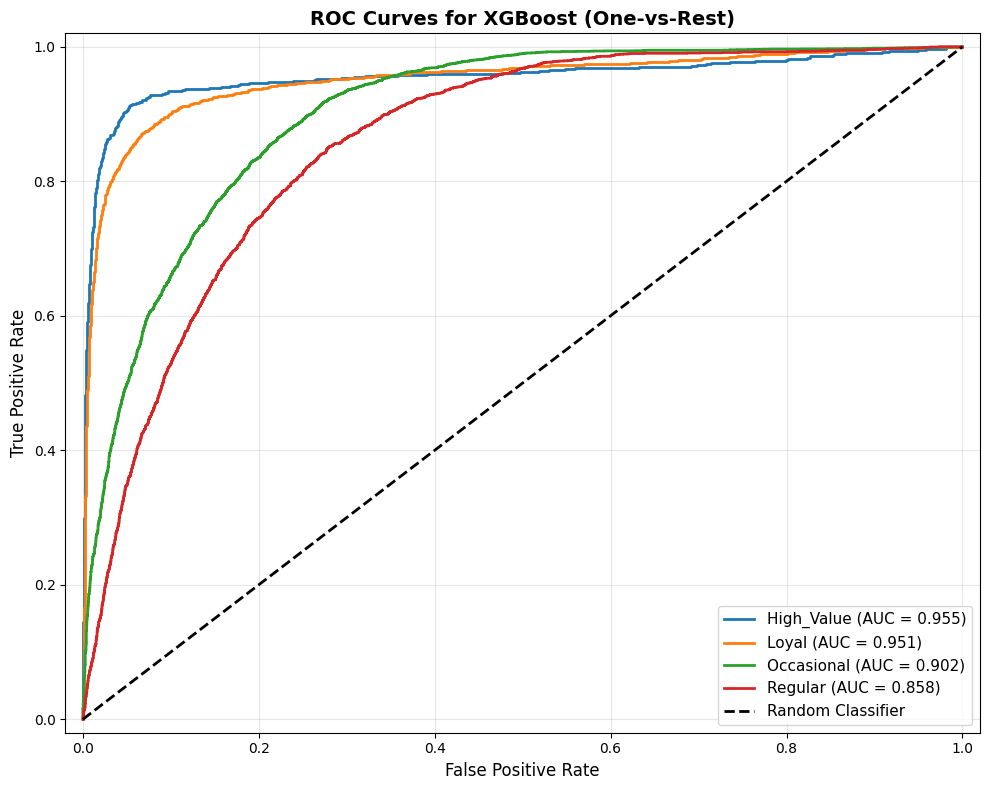

✓ ROC curves plotted for XGBoost


In [ ]:
# Plot ROC curves for the best model (XGBoost)
print("\n" + "="*70)
print("PLOTTING ROC CURVES FOR XGBOOST (Best Model)")
print("="*70)

best_model_name = 'XGBoost'
preds = predictions[best_model_name]
y_test_bin = label_binarize(preds['y_test'], classes=[0, 1, 2, 3])

segment_names = le.classes_  # ['High_Value', 'Loyal', 'Occasional', 'Regular']

# Plot ROC curve for each class (One-vs-Rest)
fig, ax = plt.subplots(figsize=(10, 8))
colors = cycle(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])

for i, color, segment_name in zip(range(4), colors, segment_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], preds['y_pred_proba'][:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, 
            label=f'{segment_name} (AUC = {roc_auc:.3f})')

# Diagonal line (random classifier)
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')

ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC Curves for {best_model_name} (One-vs-Rest)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✓ ROC curves plotted for {best_model_name}")



CONFUSION MATRIX & CLASSIFICATION REPORT FOR XGBOOST


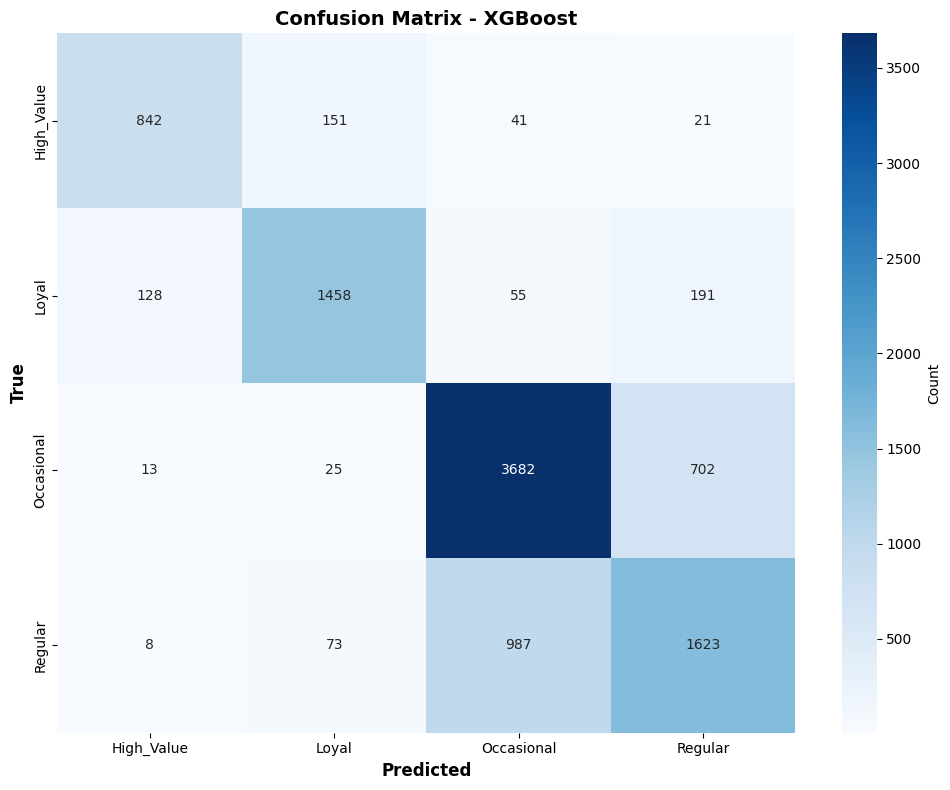


Classification Report (XGBoost):
----------------------------------------------------------------------
              precision    recall  f1-score   support

  High_Value       0.85      0.80      0.82      1055
       Loyal       0.85      0.80      0.82      1832
  Occasional       0.77      0.83      0.80      4422
     Regular       0.64      0.60      0.62      2691

    accuracy                           0.76     10000
   macro avg       0.78      0.76      0.77     10000
weighted avg       0.76      0.76      0.76     10000



In [ ]:
# Confusion Matrix and Classification Report for XGBoost
print("\n" + "="*70)
print("CONFUSION MATRIX & CLASSIFICATION REPORT FOR XGBOOST")
print("="*70)

y_pred = predictions['XGBoost']['y_pred']

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Count'}, ax=ax)
ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_ylabel('True', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nClassification Report (XGBoost):")
print("-" * 70)
print(classification_report(y_test, y_pred, target_names=le.classes_))



ROC CURVES FOR ALL MODELS (Comparison)


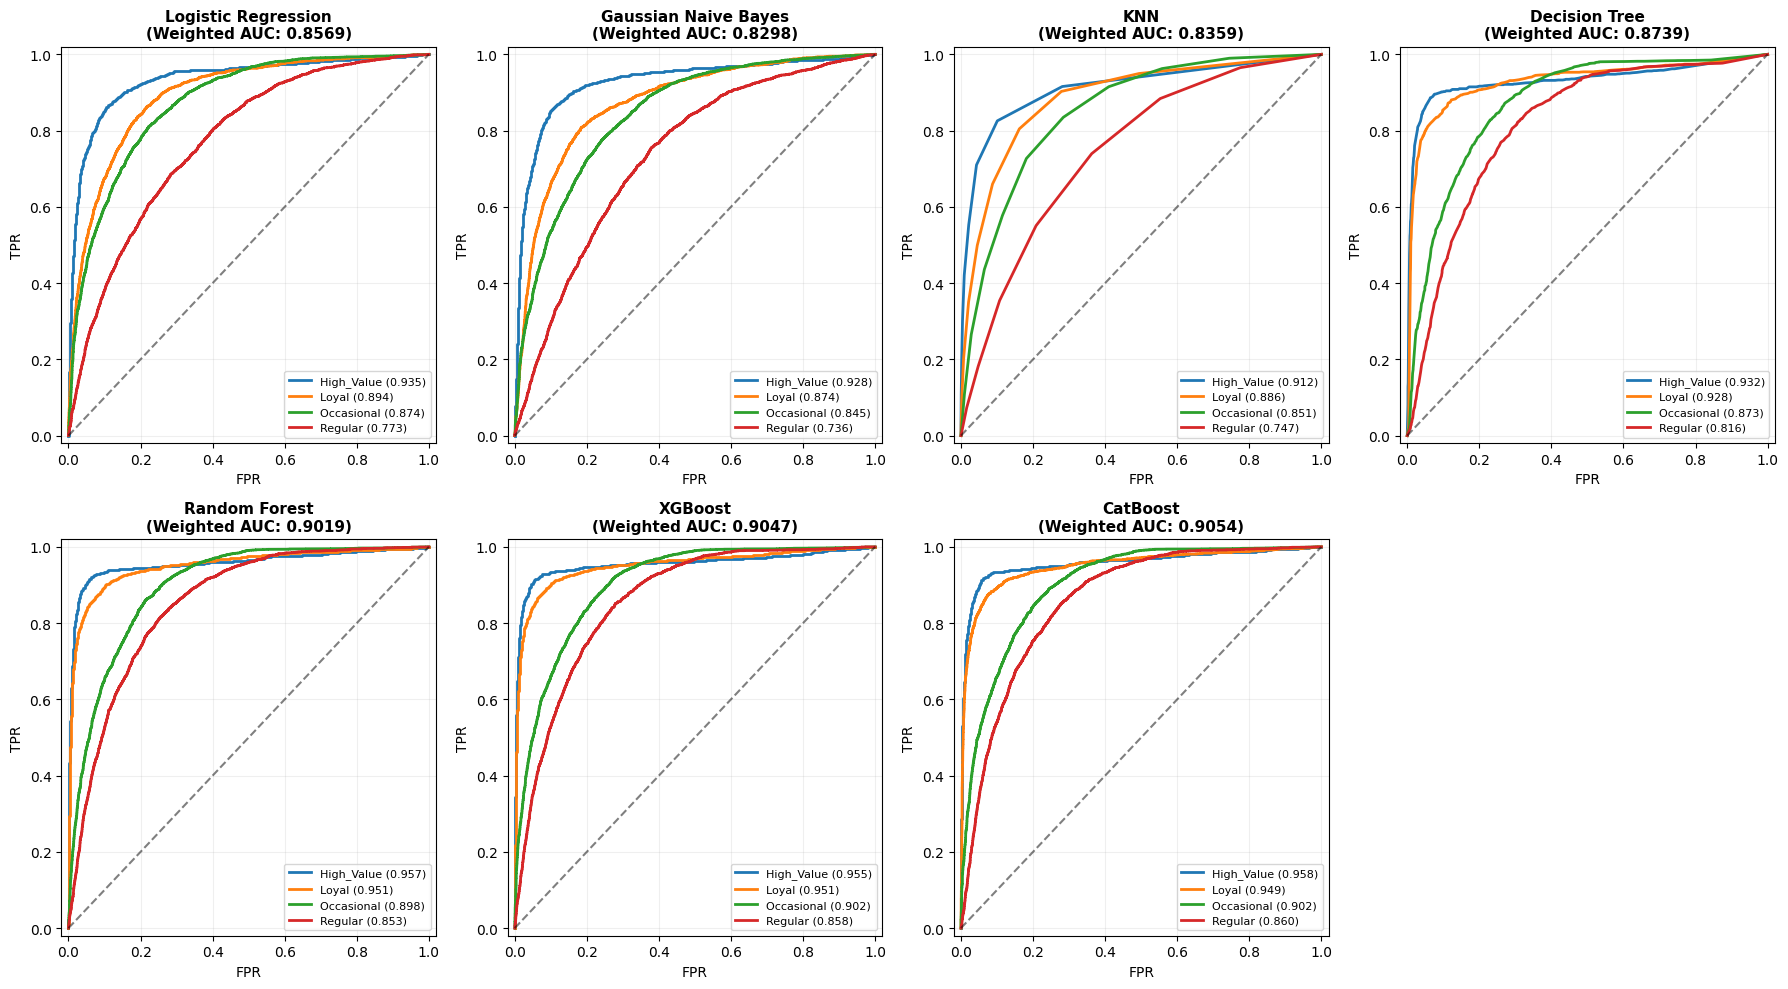

✓ ROC curves plotted for all 7 models


In [ ]:
# Plot ROC curves for ALL MODELS (Subplot Grid)
print("\n" + "="*70)
print("ROC CURVES FOR ALL MODELS (Comparison)")
print("="*70)

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

model_names = list(results.keys())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for idx, model_name in enumerate(model_names):
    ax = axes[idx]
    preds = predictions[model_name]
    y_test_bin = label_binarize(preds['y_test'], classes=[0, 1, 2, 3])
    
    # Plot ROC curves for each segment
    for i, segment_name in enumerate(le.classes_):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], preds['y_pred_proba'][:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors[i], lw=2, label=f'{segment_name} ({roc_auc:.3f})')
    
    # Random classifier line
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5)
    
    # Formatting
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
    ax.set_xlabel('FPR', fontsize=10)
    ax.set_ylabel('TPR', fontsize=10)
    weighted_auc = auc_scores[model_name]['weighted_auc']
    ax.set_title(f'{model_name}\n(Weighted AUC: {weighted_auc:.4f})', 
                 fontsize=11, fontweight='bold')
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8, loc='lower right')

# Hide the empty subplot
axes[7].set_visible(False)

plt.tight_layout()
plt.show()

print("✓ ROC curves plotted for all 7 models")


In [ ]:
# Comprehensive Evaluation Summary: All Models
print("\n" + "="*70)
print("DETAILED EVALUATION REPORT FOR ALL MODELS")
print("="*70)

for model_name in ['XGBoost', 'Random Forest', 'CatBoost']:
    print(f"\n{'='*70}")
    print(f"MODEL: {model_name}")
    print(f"{'='*70}")
    
    y_pred = predictions[model_name]['y_pred']
    
    # Display AUC scores
    print(f"\n📊 AUC Scores:")
    print(f"  Weighted AUC: {auc_scores[model_name]['weighted_auc']:.4f}")
    print(f"  Macro AUC:    {auc_scores[model_name]['macro_auc']:.4f}")
    
    # Display confusion matrix values
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n🎯 Confusion Matrix:")
    cm_df = pd.DataFrame(cm, 
                         index=[f'True {s}' for s in le.classes_],
                         columns=[f'Pred {s}' for s in le.classes_])
    print(cm_df)
    
    # Display classification report
    print(f"\n📈 Classification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))



DETAILED EVALUATION REPORT FOR ALL MODELS

MODEL: XGBoost

📊 AUC Scores:
  Weighted AUC: 0.9047
  Macro AUC:    0.9165

🎯 Confusion Matrix:
                 Pred High_Value  Pred Loyal  Pred Occasional  Pred Regular
True High_Value              842         151               41            21
True Loyal                   128        1458               55           191
True Occasional               13          25             3682           702
True Regular                   8          73              987          1623

📈 Classification Report:
              precision    recall  f1-score   support

  High_Value       0.85      0.80      0.82      1055
       Loyal       0.85      0.80      0.82      1832
  Occasional       0.77      0.83      0.80      4422
     Regular       0.64      0.60      0.62      2691

    accuracy                           0.76     10000
   macro avg       0.78      0.76      0.77     10000
weighted avg       0.76      0.76      0.76     10000


MODEL: Random For

In [ ]:
# Final Evaluation Summary Table
print("\n" + "="*70)
print("FINAL MODEL EVALUATION SUMMARY")
print("="*70)

summary_eval = pd.DataFrame({
    'Model': list(results.keys()),
    'Test Score': [results[m]['test_score'] for m in results.keys()],
    'Weighted AUC': [auc_scores[m]['weighted_auc'] for m in results.keys()],
    'Macro AUC': [auc_scores[m]['macro_auc'] for m in results.keys()],
    'Train Time (s)': [results[m]['train_time'] for m in results.keys()]
})

summary_eval = summary_eval.sort_values('Weighted AUC', ascending=False).reset_index(drop=True)
print("\n" + summary_eval.to_string(index=False))

print("\n" + "="*70)
print(f"🏆 BEST MODEL: {summary_eval.iloc[0]['Model']}")
print(f"   Weighted AUC: {summary_eval.iloc[0]['Weighted AUC']:.4f}")
print(f"   Test Score (F1-Macro): {summary_eval.iloc[0]['Test Score']:.4f}")
print("="*70)



FINAL MODEL EVALUATION SUMMARY

               Model  Test Score  Weighted AUC  Macro AUC  Train Time (s)
            CatBoost    0.759770      0.905367   0.917416       12.069975
             XGBoost    0.767371      0.904735   0.916528        9.265426
       Random Forest    0.764258      0.901950   0.914925       19.657044
       Decision Tree    0.729406      0.873853   0.887251        6.580686
 Logistic Regression    0.636234      0.856926   0.869033        5.869050
                 KNN    0.629955      0.835920   0.849081       16.338504
Gaussian Naive Bayes    0.579096      0.829822   0.845757        9.409757

🏆 BEST MODEL: CatBoost
   Weighted AUC: 0.9054
   Test Score (F1-Macro): 0.7598
